In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import scipy

from scipy.stats import norm

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

import statsmodels
import statsmodels.api as sm
import statsmodels.formula.api as smf

---

In [116]:
# data analysis global functions
def load_dataset(month, year):
    #Takes in desired month and year and outputs
    # x: hourly x data
    # y: corresponding TLV value
    # month_data: Dataframe in pivot table format with hour of day for rows and day of month for columns
    # month_temporal_melted: melted version of month_data DataFrame
    
    month_data = pd.read_csv(str(year) + " Pivot Data Tables/" + month + " TLV Pivot.csv")
    month_data = month_data.set_index('Hour of the Day')
    month_data.columns = month_data.columns.astype(int)
    month_data.index = month_data.index.astype(int)
    month_data = month_data.astype(float)

    month_temporal_melted = pd.melt(month_data.reset_index(), id_vars=['Hour of the Day'], var_name='1', value_name='Value')
    x = month_temporal_melted["Hour of the Day"]
    y = month_temporal_melted["Value"]
    
    return x, y, month_data, month_temporal_melted


def lin_reg(x, y, month, year):
    # Takes in month_data and name of month and prints out linear regression intercept, slope, and the graph. 
    # It also updates the regression error table and outputs the melted temporal dataframe for further analysis
    
    # Augmenting x matrix
    x_matrix = []
    for i in x:
        x_matrix.append([1, i])
    
    x_matrix = np.array(x_matrix)
    
    # Finding optimal linear weights
    w = np.linalg.solve(x_matrix.T @ x_matrix, x_matrix.T @ y)
    
    #w[0]: intercept, w[1]: slope
    print("intercept = w[0]:", w[0])
    print("slope = w[1]:", w[1])

    #Update MSE Risk Table
    y_true = y
    y_pred = x_matrix @ w
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    reg_errors[year].loc[month,'Linear'] = rmse
    print("RMSE using linear regression:", rmse) #Bad MSE, very large

    # Setting Plot Type
    plt.scatter(x, y, label='Data points')
    
    # Labels and title
    plt.xlabel('Hour of the Day')
    plt.ylabel('TLV')
    plt.title('TLV by Hour using Empirical Risk Minimization w.r.t. MSE')
    
    # Plot regression line
    reg_line = w[1] * x + w[0]
    plt.plot(x, reg_line, color='red', label=f'MSE Reg Line')
    
    # Show the plot
    plt.legend()
    plt.show()
    
    return x_matrix

def knn_predict(X_train, y_train, x, k=1):
    predictions = []
    
    for x in X_test:
        # Calculate distances between the test point and all training points
        distances = np.linalg.norm(X_train - x, axis=1)
        # Find the indices of the k nearest neighbors
        nearest_neighbors = np.argpartition(distances, k, axis=0)[:k]
        # Average the target values of the k nearest neighbors
        prediction = np.mean(y_train[nearest_neighbors])
        predictions.append(prediction)
    
    return np.array(predictions)

# automatically clustering values

def create_clusters(melted_temporal_df, k=3):
    # Takes in a melted temporal df and desired number of clusters
    # Outputs a copy of the melted temporal df with the addition of a new cluster column and the scaled and unscaled centroids
    
    df = melted_temporal_df.copy()
    scaler = StandardScaler()
    melted_temporal_df_scaled = scaler.fit_transform(df[["Hour of the Day", "Value"]])

    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)

    df['Cluster'] = kmeans.fit_predict(melted_temporal_df_scaled)  
    scaled_centroids = kmeans.cluster_centers_
    unscaled_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

    return df, melted_temporal_df_scaled, scaled_centroids, unscaled_centroids

# def create_clusters(melted_temporal_df, k=3):
#     # Copy original df
#     df = melted_temporal_df.copy()

#     # Scale only 'Hour of the Day'
#     scaler = StandardScaler()
#     hour_scaled = scaler.fit_transform(df[["Hour of the Day"]])

#     # Fit KMeans only on the hour feature
#     kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
#     df['Cluster'] = kmeans.fit_predict(hour_scaled)

#     # Centroids (scaled and unscaled)
#     scaled_centroids = kmeans.cluster_centers_
#     unscaled_centroids = scaler.inverse_transform(kmeans.cluster_centers_)

#     return df, hour_scaled, scaled_centroids, unscaled_centroids

def create_cluster_scatterplots(melted_temporal_df, create_clusters):
    # Takes in a melted temporal dataframe and the create_clusters function
    # Outputs two scatterplots, one scaled and one unscaled, with data grouped into clusters and centroids identified

    clusters = create_clusters(melted_temporal_df)
    
    # x_scaled = clusters[1].T[0]
    # y_scaled = clusters[1].T[1]

    # plt.figure(figsize=(8, 6))
    # sns.scatterplot(x=x_scaled, y=y_scaled, hue=clusters[0]['Cluster'])
    # plt.scatter(clusters[2][:, 0], clusters[2][:, 1], color='red', marker='X', s=200, label='Centroids')
    # plt.title('K-Means Clustering Scaled')
    # plt.legend()
    # plt.show()


    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=melted_temporal_df['Hour of the Day'], y=melted_temporal_df['Value'], hue=clusters[0]['Cluster'])
    plt.scatter(clusters[3][:, 0], clusters[3][:, 1], color='red', marker='X', s=200, label='Centroids')
    plt.title('K-Means Clustering w/ Original Data')
    plt.ylabel('TLV')
    plt.legend()
    plt.show()

def analyze_cluster_dist(cluster_data):
    # Takes in a melted temporal dataframe with a column for data clusters
    # Outputs a grid of the scatterplot and histogram distribution for each cluster
    fig, axs = plt.subplots(3, 2, figsize=(12, 12))
    
    # For Loop to plot in the grid
    for i in np.unique(cluster_data['Cluster']):
        # Histogram to look at data distribution
        cluster = cluster_data[cluster_data['Cluster'] == i]
        x = cluster["Hour of the Day"]
        y = cluster["Value"]
    
        # Histogram Plot
        sns.histplot(y, kde=True, bins=25, color='blue', stat='density', label='Histogram', ax=axs[i, 0])
    
        # Normal Distribution Plot in Comparison
        y_mean = np.mean(y)
        y_std = np.std(y, ddof=1)
        x_norm = np.linspace(min(y), max(y), 1000)
        y_norm = norm.pdf(x_norm, y_mean, y_std)
        
        axs[i, 0].plot(x_norm, y_norm, color='red', label='Normal Distribution')
        axs[i, 0].set_title(f'Density Distribution of TLV (in $) for Cluster {i}')
        axs[i, 0].set_xlabel('TLV')
        axs[i, 0].legend()
    
        # Scatter Plot
        sns.scatterplot(x=x, y=y, ax=axs[i, 1])
        axs[i, 1].set_title(f'TLV at Certain Hours of the Day for Cluster {i}')
        axs[i, 1].set_ylabel('TLV')
    
    # Adjust layout to prevent overlap
    plt.tight_layout()
    
    # Show the plots
    plt.show()


def compute_MSE_weights(cluster_data):
    # Takes in a melted temporal dataframe with a column for data clusters
    # Outputs a dictionary with each key being a unique cluster in the data and each value an array of weights for weight vector
    
    weights_dict = {}
    for i in np.unique(cluster_data['Cluster']):
        
        cluster = cluster_data[cluster_data['Cluster'] == i]

        x = cluster["Hour of the Day"]
        y = cluster["Value"]
        
        #Augmenting X
        x_matrix = []
        for j in x:
            x_matrix.append([1, j])
        x_matrix = np.array(x_matrix)
        
        w = np.linalg.solve(x_matrix.T @ x_matrix, x_matrix.T @ y)

        weights_dict[i] = w

    return weights_dict
    
# # Calculating risk wrt square loss

def compute_square_risk(cluster_data, compute_MSE_weights):
    """
    Computes the overall mean squared error (MSE) across all clusters.

    Args:
        cluster_data: melted dataframe with 'Cluster', 'Hour of the Day', and 'Value'
        compute_MSE_weights: function that returns a dict of cluster weights

    Returns:
        A single float representing the overall MSE across all clusters.
    """
    weights_dict = compute_MSE_weights(cluster_data)

    all_errors = []
    all_counts = 0

    for i in np.unique(cluster_data['Cluster']):
        cluster = cluster_data[cluster_data['Cluster'] == i]
        w = np.array(weights_dict[i])

        x = np.array(cluster["Hour of the Day"])
        y = np.array(cluster["Value"])
        x_matrix = np.column_stack((np.ones_like(x), x))

        preds = x_matrix @ w
        squared_errors = (preds - y) ** 2

        all_errors.extend(squared_errors)
        all_counts += len(y)

    total_mse = np.sum(all_errors) / all_counts
    return np.sqrt(total_mse)


def cluster_MSE_reg_graphs(cluster_data, compute_MSE_weights):
    plt.figure(figsize=(10, 6))
    x = cluster_data['Hour of the Day']
    y = cluster_data['Value']
    
    sns.scatterplot(x=x, y=y,  hue=cluster_data['Cluster'])

    # Labels and title
    plt.xlabel('Hours of the Day')
    plt.ylabel('TLV')
    plt.title('Regression wrt MSE for 3 Clusters for TLV per Hour of the Day')

    w = compute_MSE_weights(cluster_data)
    colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']   

    for i, color in zip(np.unique(cluster_data['Cluster']), colors):

        cluster = cluster_data[cluster_data['Cluster'] == i]
            
        # Plot regression line
        reg_x_min = cluster.sort_values(by="Hour of the Day", ascending=True).iloc[0]['Hour of the Day']
        reg_x_max = cluster.sort_values(by="Hour of the Day", ascending=False).iloc[0]['Hour of the Day']
        reg_x_range = np.linspace(reg_x_min, reg_x_max, 1000)
        reg_line = w[i][1] * reg_x_range + w[i][0]
        plt.plot(reg_x_range, reg_line, color=color, label=f'MSE Reg Line ≈ {np.round(w[i][0], 2)} Hour + {np.round(w[i][1], 2)}')

        
    # Show the plot
    plt.legend(loc='lower left', framealpha=0.5, fontsize=8)
    plt.show()

def gaussian_weights(x, y, mu, sigma = 1):
    #Given x, y, and mu, generates optimal weight vector
    
    Phi = np.zeros((len(x), len(mu))) # Create matrix of 0's

    # For each x, generates a vector of Gaussian mappings and inputs in respective spot in Phi
    for i in range(len(x)):
        for j in range(len(mu)):
            Phi[i,j] = np.exp(-((x[i] - mu[j]) ** 2) / (sigma ** 2))

    # Finds optimal weight vector
    w = np.linalg.solve(Phi.T @ Phi, Phi.T @ y)
        
    return w

def plot_h(x, mu, w, sigma = 2):
    # Creates a line from specified x values with the predicted H(x) values
     #generates array of x values
    H = 0

    #computes H(x) for each x
    for i in range(len(w)):
        H += w[i] * (np.exp(-((x - mu[i]) ** 2) / (sigma ** 2)))
    
    return H 

### 2024 January

In [105]:
month = "January"
year = "2024"

jan24_data = load_dataset(month, year)[2]
jan24_data_temporal_melted = load_dataset(month, year)[3]

x = load_dataset(month, year)[0]
y = load_dataset(month, year)[1]
jan24_data.head()

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
Hour of the Day,,,,,,,,,,,,,,,,,,,,,
0,177.478436,186.590149,163.130485,205.813273,183.654301,142.950007,189.220797,131.728751,179.528021,197.791916,...,146.284715,171.666910,195.121009,151.294090,216.931612,200.374696,179.862041,175.582862,175.182656,132.820804
1,171.730800,162.926774,159.087839,200.314868,193.890616,128.104025,191.760397,132.586752,173.652539,180.989446,...,137.638157,171.653404,172.048585,166.748393,154.565310,195.057764,185.692403,162.156991,158.486559,135.335344
2,194.218931,176.548003,156.096226,220.599234,204.466608,183.951102,179.164417,130.327056,174.919317,177.751206,...,159.898448,168.018039,171.227015,173.604681,174.623426,193.759602,200.777557,152.513504,168.976863,135.212569
3,191.388264,169.326314,155.615547,204.216241,197.810023,186.023749,188.471304,165.026129,161.797237,169.370577,...,160.392606,172.586134,171.147551,168.110040,190.964730,168.372278,187.236431,150.566127,160.483108,164.854253
4,193.275623,171.871338,153.249343,219.076831,197.689883,171.224081,184.116422,171.148010,163.079664,164.587624,...,167.017282,170.587763,165.990832,169.955488,197.548212,164.519542,186.711966,154.910572,162.558297,174.586383


In [106]:
# MSE per month per regression type dataframe
reg_errors = {}

months = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December"
]

reg_types = [
    "Linear", "KNN", "Linear+Cluster","Gaussian Basis"
]

reg_errors[year] = pd.DataFrame(index=months, columns=reg_types)

#### Linear Regression

intercept = w[0]: 137.19976844995642
slope = w[1]: -0.7320791490613131
RMSE using linear regression: 67.08551500848233


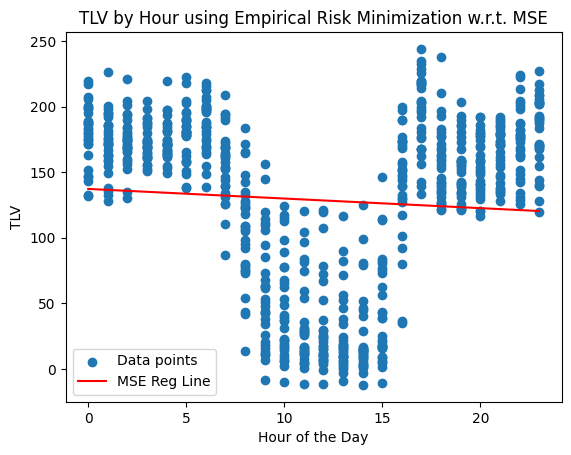

In [107]:
x_matrix = lin_reg(x, y, month, year)

#### KNN Regression

In [108]:
# Splitting data into test and training data
X_train, X_test, y_train, y_test = train_test_split(x_matrix, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

k = round(np.sqrt(len(x_matrix))) #letting k = square root of n
y_train = np.array(y_train)
y_pred = knn_predict(X_train, y_train, X_test, k=k) #KNN predictons for TLV
print("KNN TLV predictions:",y_pred)

KNN TLV predictions: [ 60.57484496  38.28838998 174.04065381  31.93380981 181.30423595
  60.57484496 158.35900525 141.1452813  158.35900525 195.93488756
  31.93380981 156.31800453  38.28838998 176.74356978 174.04065381
 174.04065381  33.1501766   44.22492302 162.53999446 171.39994783
  44.26986273  25.51076581  44.22492302  31.93380981  25.51076581
 155.67321528  44.26986273 162.53999446 171.84425906 170.98739037
 172.90943826 181.30423595 176.74356978 174.04065381 176.74356978
  33.1501766  176.52768118 176.52768118  38.28838998 176.52768118
  60.57484496 158.35900525 170.98739037 171.84425906 181.30423595
 195.93488756 171.84425906 162.53999446  44.22492302  38.28838998
 165.72866072 176.52768118 155.67321528 156.31800453  60.57484496
 176.74356978 176.74356978 181.30423595 180.44240101 181.30423595
  31.93380981  31.93380981 165.72866072 171.39994783  38.28838998
 180.44240101 176.52768118 172.90943826 165.72866072 172.90943826
  60.57484496 158.35900525 176.52768118 176.52768118 15

MSE for KNN: 29.33205096336211


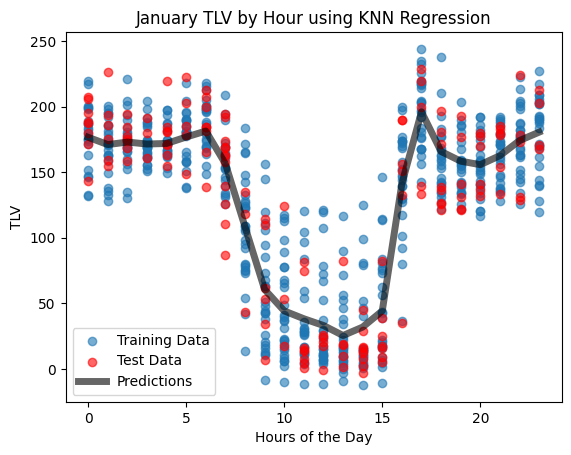

In [109]:
# Evaluate the model
mse = np.sqrt(mean_squared_error(y_test, y_pred))
reg_errors[year].loc[month,'KNN'] = mse
print(f"MSE for KNN: {mse}") # Much lower than MSE regression!

# Sort the test data and corresponding predictions for smooth plotting
sorted_indices = np.argsort(X_test[:,1].flatten())
X_test_sorted = X_test[:,1].flatten()[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Training Data
plt.scatter(X_train[:,1], y_train, label="Training Data", alpha=0.6)
# Testing Data
plt.scatter(X_test[:,1], y_test, label="Test Data", color="red", alpha=0.6)
# Predicted regression
plt.plot(X_test_sorted, y_pred_sorted, label="Predictions", color="black", alpha=0.6, linewidth = 5)

# Plot settings
plt.legend()
plt.xlabel("Hours of the Day")
plt.ylabel("TLV")
plt.title("January TLV by Hour using KNN Regression")
plt.show()

#### Cluster + Linear Regression

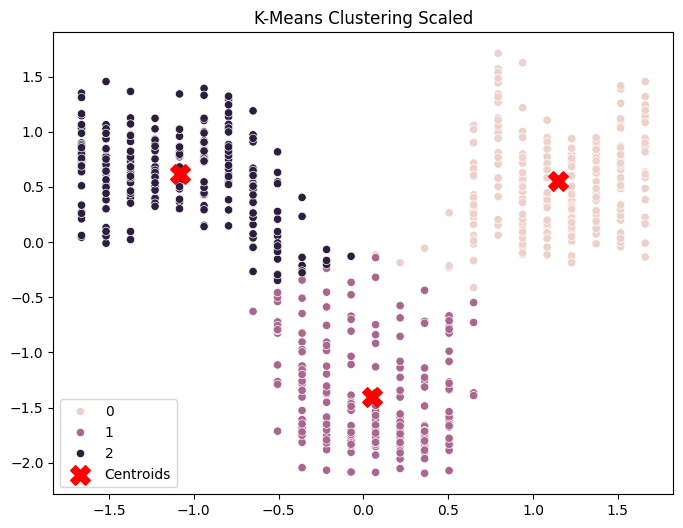

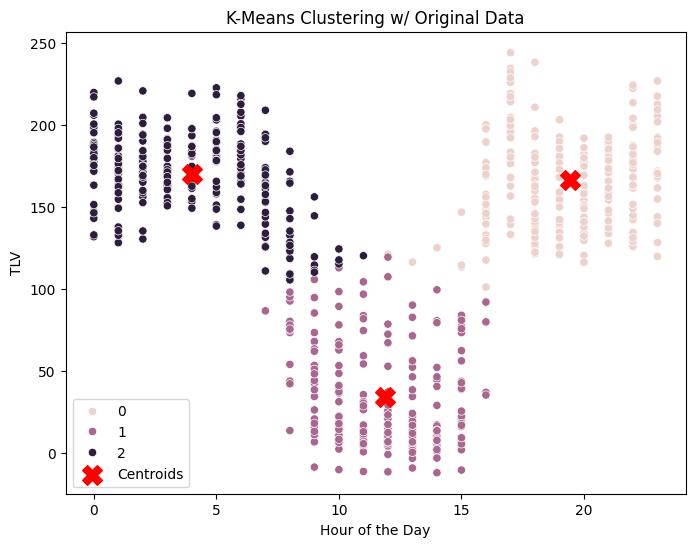

In [110]:
create_cluster_scatterplots(jan24_data_temporal_melted, create_clusters)

In [111]:
jan24_data_temporal_melted = create_clusters(jan24_data_temporal_melted)[0]
jan24_data_temporal_melted

,Hour of the Day,1,Value,Cluster
0,0,1,177.478436,2
1,1,1,171.730800,2
2,2,1,194.218931,2
3,3,1,191.388264,2
4,4,1,193.275623,2
...,...,...,...,...
739,19,31,131.084626,0
740,20,31,132.119519,0
741,21,31,178.246433,0
742,22,31,151.426078,0


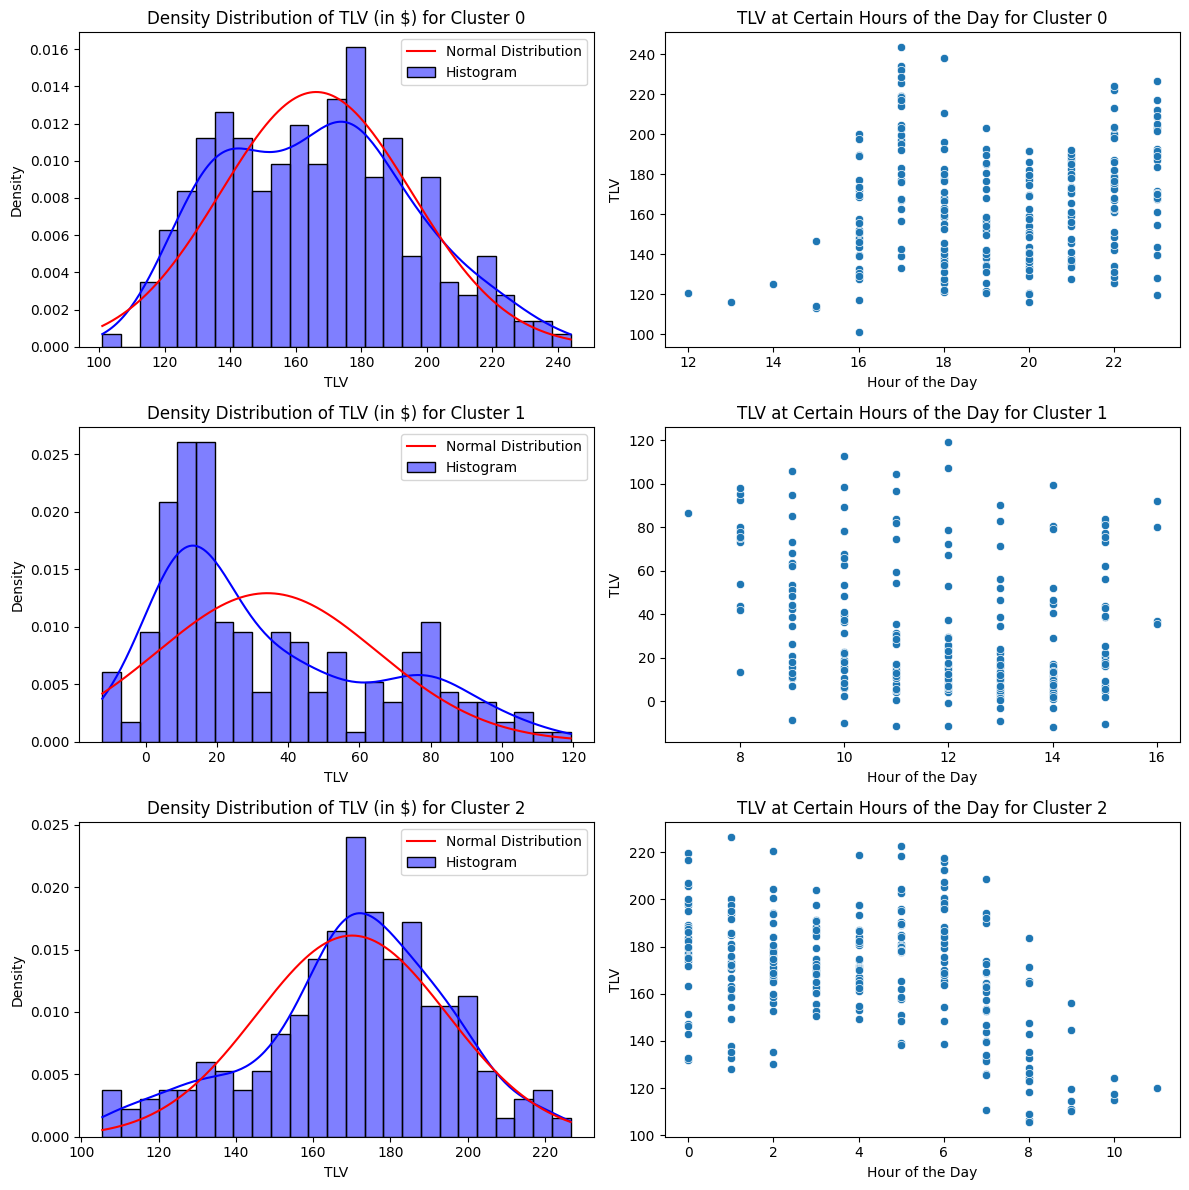

cluster weights:  {np.int32(0): array([128.99562733,   1.91803632]), np.int32(1): array([74.47180309, -3.39578952]), np.int32(2): array([183.62994012,  -3.38948938])}
cluster square loss risk:  27.108538376845626


In [112]:
analyze_cluster_dist(jan24_data_temporal_melted)
print("cluster weights: ", compute_MSE_weights(jan24_data_temporal_melted)) 
print("cluster square loss risk: ", compute_square_risk(jan24_data_temporal_melted, compute_MSE_weights))

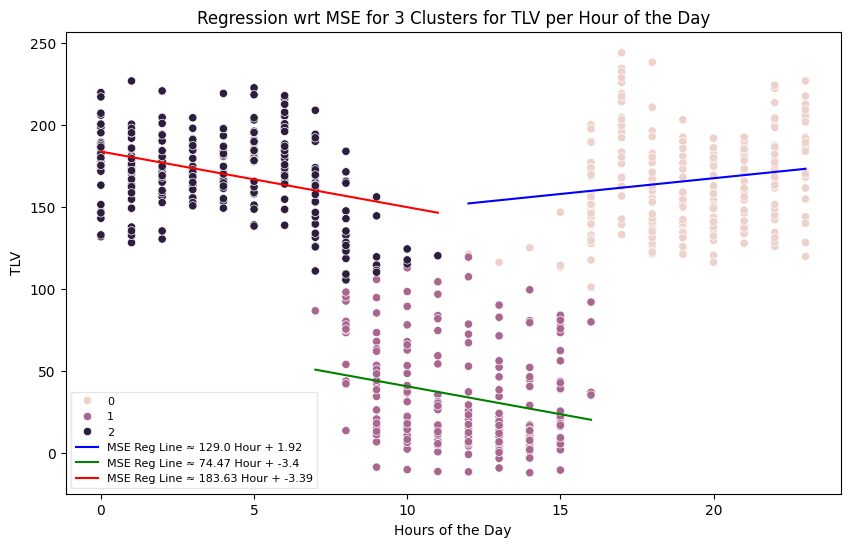

In [113]:
cluster_MSE_reg_graphs(jan24_data_temporal_melted, compute_MSE_weights)

In [12]:
# Risk for this type of pricing scheme:


risk = compute_square_risk(jan24_data_temporal_melted, compute_MSE_weights)
reg_errors[year].loc[month,'Linear+Cluster'] = risk

print("empirical risk: ", risk)

empirical risk:  27.108538376845626


#### Clustering with vertical binning

In [132]:
def ml_guided_vertical_clusters_with_centroids(df, k=3):
    df = df.copy()

    # Step 1: Cluster based only on 'Value'
    kmeans = KMeans(n_clusters=k, random_state=42)
    df['Initial Cluster'] = kmeans.fit_predict(df[['Value']])

    # Step 2: Bin time (x-axis) into k vertical regions
    df['Hour Bin'] = pd.cut(df['Hour of the Day'], bins=k, labels=False)

    # Step 3: Assign a **unique final cluster** label to each time bin
    df['Cluster'] = df['Hour Bin']  # directly use hour bins as cluster labels

    # Step 4: Compute unscaled centroids (mean of Hour and Value per Final Cluster)
    centroids = (
        df.groupby('Cluster')[['Hour of the Day', 'Value']]
        .mean()
        .reset_index()
        .values
    )

    return df, centroids


In [133]:
final_jan24_data_temporal_melted = ml_guided_vertical_clusters_with_centroids(jan24_data_temporal_melted)[0]
final_jan24_data_centroids = ml_guided_vertical_clusters_with_centroids(jan24_data_temporal_melted)[1]
final_jan24_data_temporal_melted

,Hour of the Day,1,Value,Cluster,Initial Cluster,Hour Bin
0,0,1,177.478436,0,1,0
1,1,1,171.730800,0,1,0
2,2,1,194.218931,0,1,0
3,3,1,191.388264,0,1,0
4,4,1,193.275623,0,1,0
...,...,...,...,...,...,...
739,19,31,131.084626,2,2,2
740,20,31,132.119519,2,2,2
741,21,31,178.246433,2,1,2
742,22,31,151.426078,2,2,2


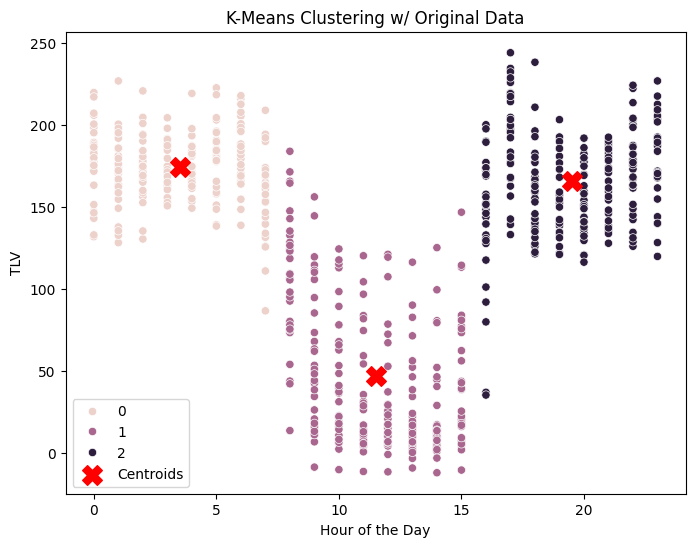

In [135]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=final_jan24_data_temporal_melted['Hour of the Day'], y=final_jan24_data_temporal_melted['Value'], hue=final_jan24_data_temporal_melted['Cluster'])
plt.scatter(final_jan24_data_centroids[:, 1], final_jan24_data_centroids[:, 2], color='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering w/ Original Data')
plt.ylabel('TLV')
plt.legend()
plt.show()

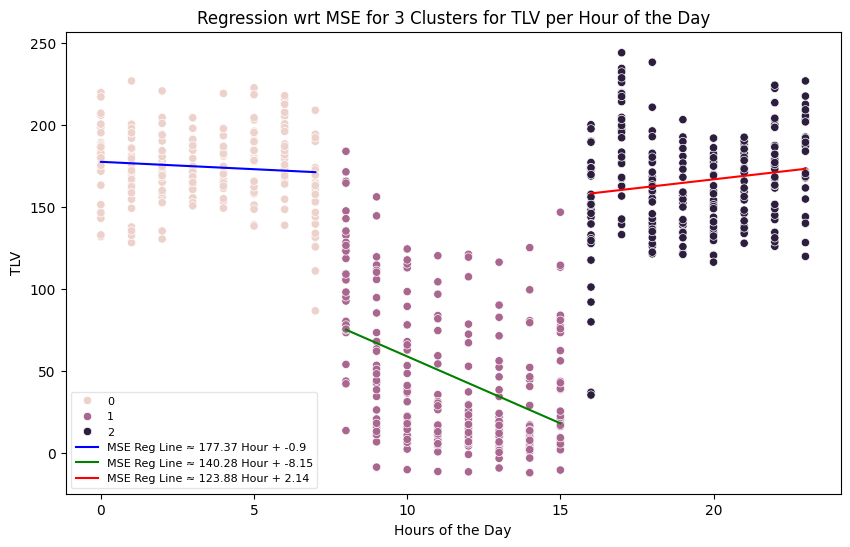

In [140]:
compute_square_risk(final_jan24_data_temporal_melted, compute_MSE_weights)
cluster_MSE_reg_graphs(final_jan24_data_temporal_melted, compute_MSE_weights)

#### Gaussian Basis Regression

In [13]:
# Parameters
mu = np.linspace(0, 23, 10) # Uses 10 mu's equally spaced out
sigma = (max(x) - min(x)) / 10 #using (max(x) - min(x))/(# of basis functions) for sigma


w = gaussian_weights(x, y, mu, sigma) #Optimal weight vectors given x and y in dataset

print("sigma: ", sigma)
print("weight vector: ", w)

sigma:  2.3
weight vector:  [151.54094483  78.5893422  144.06698631  73.21560299  19.22444729
   1.29568029  39.06405936 156.33168053  51.30663826 167.80128317]


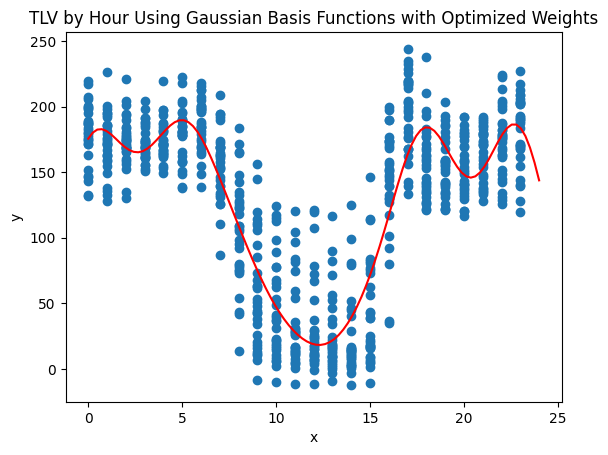

In [14]:
# Plotting H(x) prediction line on data
x_reg = np.linspace(0, 24, 100)
H= plot_h(x_reg, mu, w, sigma)

plt.plot(x_reg, H, color="red")
plt.scatter(x, y)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('TLV by Hour Using Gaussian Basis Functions with Optimized Weights')
plt.show()


In [15]:
# Calculating Risk
pred_y = plot_h(x, mu, w, sigma)
risk = np.sqrt(mean_squared_error(y, pred_y))
reg_errors[year].loc[month,'Gaussian Basis'] = risk

print("risk w.r.t. RMSE: ", risk)

risk w.r.t. RMSE:  31.911611163367805


### 2024 Complex 4 Cluster Linear x Gaussian 

In [16]:
jan24_melted = load_dataset(month, year)[3]
jan24_nonpeak = jan24_melted[(jan24_melted['Hour of the Day'] < 15) | (jan24_melted['Hour of the Day'] > 20)]
jan24_peak = jan24_melted[(jan24_melted['Hour of the Day'] >=  15) & (jan24_melted['Hour of the Day'] <= 20)]

In [17]:
jan24_nonpeak_clustered = create_clusters(jan24_nonpeak, k = 3)[0]
jan24_nonpeak_clustered_centroids = create_clusters(jan24_nonpeak, k = 3)[3]

jan24_peak_clustered = create_clusters(jan24_peak, k = 1)[0]
jan24_peak_clustered_centroids = create_clusters(jan24_peak, k = 1)[3]
jan24_peak_clustered['Cluster'] = 3

jan24_centroids = combined = np.concatenate((jan24_nonpeak_clustered_centroids, jan24_peak_clustered_centroids))

jan24_clustered = pd.concat([jan24_nonpeak_clustered, jan24_peak_clustered], ignore_index=True)
jan24_clustered

,Hour of the Day,1,Value,Cluster
0,0,1,177.478436,1
1,1,1,171.730800,1
2,2,1,194.218931,1
3,3,1,191.388264,1
4,4,1,193.275623,1
...,...,...,...,...
739,16,31,91.888414,3
740,17,31,142.492965,3
741,18,31,134.894130,3
742,19,31,131.084626,3


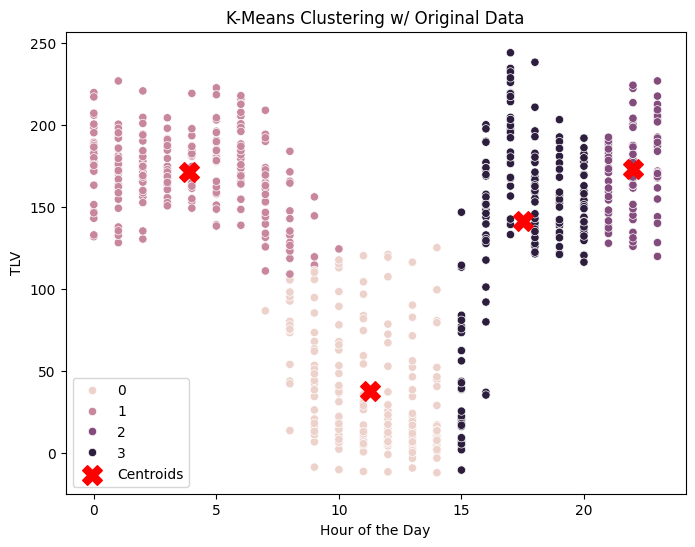

In [18]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=jan24_clustered['Hour of the Day'], y=jan24_clustered['Value'], hue=jan24_clustered['Cluster'])
plt.scatter(jan24_centroids[:, 0], jan24_centroids[:, 1], color='red', marker='X', s=200, label='Centroids')
plt.title('K-Means Clustering w/ Original Data')
plt.ylabel('TLV')
plt.legend()
plt.show()

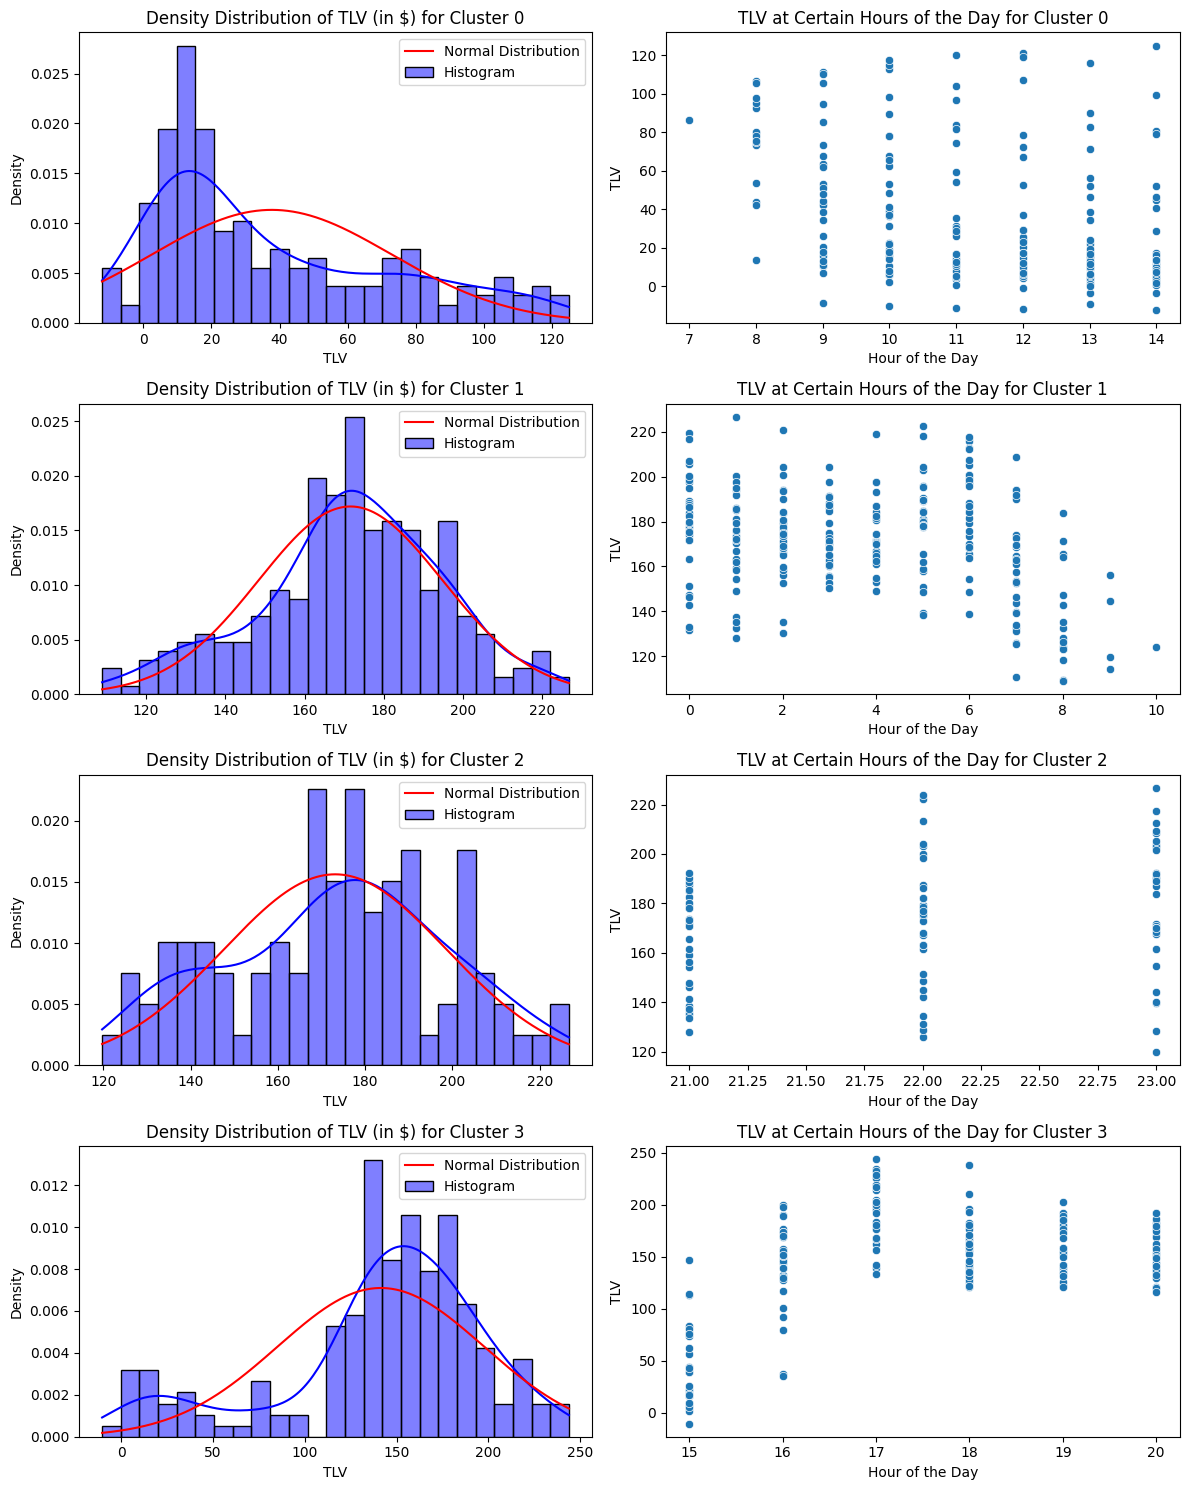

In [19]:
fig, axs = plt.subplots(4, 2, figsize=(12, 15))

# For Loop to plot in the grid
for i in np.unique(jan24_clustered['Cluster']):
    # Histogram to look at data distribution
    cluster = jan24_clustered[jan24_clustered['Cluster'] == i]
    x = cluster["Hour of the Day"]
    y = cluster["Value"]

    # Histogram Plot
    sns.histplot(y, kde=True, bins=25, color='blue', stat='density', label='Histogram', ax=axs[i, 0])

    # Normal Distribution Plot in Comparison
    y_mean = np.mean(y)
    y_std = np.std(y, ddof=1)
    x_norm = np.linspace(min(y), max(y), 1000)
    y_norm = norm.pdf(x_norm, y_mean, y_std)
    
    axs[i, 0].plot(x_norm, y_norm, color='red', label='Normal Distribution')
    axs[i, 0].set_title(f'Density Distribution of TLV (in $) for Cluster {i}')
    axs[i, 0].set_xlabel('TLV')
    axs[i, 0].legend()

    # Scatter Plot
    sns.scatterplot(x=x, y=y, ax=axs[i, 1])
    axs[i, 1].set_title(f'TLV at Certain Hours of the Day for Cluster {i}')
    axs[i, 1].set_ylabel('TLV')

# Adjust layout to prevent overlap
plt.tight_layout()

# Show the plots
plt.show()

In [21]:
jan24_peak_x = np.array(jan24_peak['Hour of the Day'])
jan24_peak_y = np.array(jan24_peak['Value'])

jan24_peak_n = 4
jan24_peak_mu = np.linspace(min(jan24_peak_x), max(jan24_peak_x), jan24_peak_n)
jan24_peak_sigma = (max(jan24_peak_x) - min(jan24_peak_x)) / jan24_peak_n

jan24_peak_w = gaussian_weights(jan24_peak_x, jan24_peak_y, jan24_peak_mu, jan24_peak_sigma) #Optimal weight vectors given x and y in dataset

print("sigma: ", jan24_peak_sigma)
print("weight vector: ", jan24_peak_w)

sigma:  1.25
weight vector:  [ 14.03215607 174.71646098  98.26398476 139.31686348]


In [82]:
len(jan24_peak_x)

186

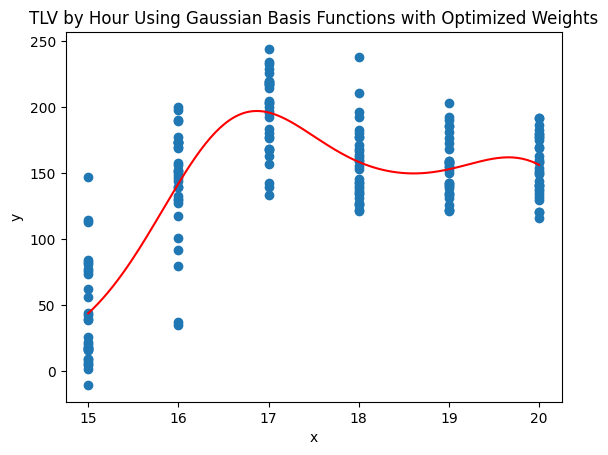

In [22]:
# Plotting H(x) prediction line on data
x_reg = np.linspace(15, 20, 186)
H= plot_h(x_reg, jan24_peak_mu, jan24_peak_w, jan24_peak_sigma)

plt.plot(x_reg, H, color="red")
plt.scatter(jan24_peak_x, jan24_peak_y)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('TLV by Hour Using Gaussian Basis Functions with Optimized Weights')
plt.show()


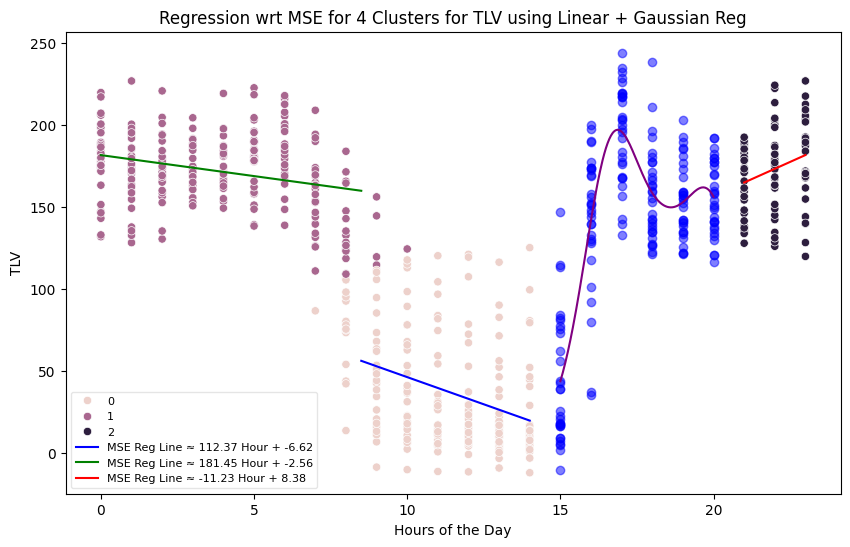

In [23]:
# cluster_MSE_reg_graphs(jan24_nonpeak_clustered, compute_MSE_weights)

plt.figure(figsize=(10, 6))
nonpeak_x = jan24_nonpeak_clustered['Hour of the Day']
nonpeak_y = jan24_nonpeak_clustered['Value']

sns.scatterplot(x=nonpeak_x, y=nonpeak_y,  hue=jan24_nonpeak_clustered['Cluster'])

# Labels and title
plt.xlabel('Hours of the Day')
plt.ylabel('TLV')
plt.title('Regression wrt MSE for 4 Clusters for TLV using Linear + Gaussian Reg')

w = compute_MSE_weights(jan24_nonpeak_clustered)
colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']


boundary_sum = 0

for i, color in zip(np.unique(jan24_nonpeak_clustered['Cluster']), colors):

    cluster = jan24_nonpeak_clustered[jan24_nonpeak_clustered['Cluster'] == i]

    if i == 1:
        boundary_sum += cluster.sort_values(by="Hour of the Day", ascending=False).iloc[0]['Hour of the Day']
    if i == 0:
        boundary_sum += cluster.sort_values(by="Hour of the Day", ascending=True).iloc[0]['Hour of the Day']

boundary_01 = boundary_sum/2
        

for i, color in zip(np.unique(jan24_nonpeak_clustered['Cluster']), colors):

    cluster = jan24_nonpeak_clustered[jan24_nonpeak_clustered['Cluster'] == i]
        
    # Plot regression line
    if i == 1:
        reg_x_max = boundary_01
        reg_x_min = cluster.sort_values(by="Hour of the Day", ascending=True).iloc[0]['Hour of the Day']
    elif i == 0:
        reg_x_max = cluster.sort_values(by="Hour of the Day", ascending=False).iloc[0]['Hour of the Day']
        reg_x_min = boundary_01
    else:
        reg_x_min = cluster.sort_values(by="Hour of the Day", ascending=True).iloc[0]['Hour of the Day']
        reg_x_max = cluster.sort_values(by="Hour of the Day", ascending=False).iloc[0]['Hour of the Day']
    reg_x_range = np.linspace(reg_x_min, reg_x_max, 1000)
    reg_line = w[i][1] * reg_x_range + w[i][0]
    plt.plot(reg_x_range, reg_line, color=color, label=f'MSE Reg Line ≈ {np.round(w[i][0], 2)} Hour + {np.round(w[i][1], 2)}')

peak_x = jan24_peak_clustered['Hour of the Day']
peak_y = jan24_peak_clustered['Value']

plt.plot(x_reg, H, color="purple")
plt.scatter(peak_x, peak_y, color = "blue", alpha=0.5)

# Show the plot
plt.legend(loc='lower left', framealpha=0.5, fontsize=8)
plt.show()



In [25]:
weights_dict = compute_MSE_weights(jan24_nonpeak_clustered)

actual_values = []
pred_values = []

for i in np.unique(jan24_nonpeak_clustered['Cluster']):
    cluster = jan24_nonpeak_clustered[jan24_nonpeak_clustered['Cluster'] == i]
    w = np.array(weights_dict[i])

    x = np.array(cluster["Hour of the Day"])
    y = np.array(cluster["Value"])  # get actual values as array

    # Augmenting X with bias term
    x_matrix = np.column_stack((np.ones_like(x), x))

    # Store actual and predicted values
    actual_values.extend(y)
    pred_values.extend(x_matrix @ w)  # vectorized prediction

nonpeak_values = pd.DataFrame({'Pred Values': pred_values, 'Actual Values': actual_values})

In [26]:
pred_peak_y = plot_h(jan24_peak_x, jan24_peak_mu, jan24_peak_w, jan24_peak_sigma)
peak_values = pd.DataFrame({'Pred Values': pred_peak_y, 'Actual Values': jan24_peak_y})

jan24_values = pd.concat([nonpeak_values, peak_values], ignore_index=True)
jan24_values

,Pred Values,Actual Values
0,39.508773,120.130870
1,32.884968,120.975605
2,26.261163,116.195798
3,19.637358,125.055825
4,46.132578,89.261650
...,...,...
739,141.880143,91.888414
740,195.744005,142.492965
741,158.335017,134.894130
742,152.756902,131.084626


In [27]:
risk2 = np.sqrt(mean_squared_error(jan24_values['Pred Values'], jan24_values['Actual Values']))

risk2

np.float64(27.810099702531488)

---

### 2022 January

In [28]:
month = "January"
year = "2022"

jan22_data = load_dataset(month, year)[2]
jan22_data_temporal_melted = load_dataset(month, year)[3]

x = load_dataset(month, year)[0]
y = load_dataset(month, year)[1]
jan22_data.head()

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
Hour of the Day,,,,,,,,,,,,,,,,,,,,,
0,60.396590,67.469629,71.065107,74.190610,70.672511,68.350969,70.799985,67.644622,68.443076,68.221404,...,64.708025,66.057053,69.825556,64.766477,72.369823,66.338270,70.138320,68.410674,67.611570,66.733698
1,62.631308,68.508597,71.727331,74.523762,71.806750,78.886729,70.688994,67.233219,67.674766,68.303227,...,65.665178,65.601124,69.825114,64.610557,69.511709,69.855923,70.389777,69.888002,66.937630,67.376550
2,62.726845,67.440851,67.453706,73.817002,68.050789,68.708621,71.254112,66.481947,66.858605,67.986986,...,63.589852,65.806674,69.179653,62.697682,71.177231,68.205936,69.716221,66.731183,63.823701,57.779013
3,62.852241,67.156518,65.869732,73.941857,69.435151,69.952000,71.284721,66.576070,65.994284,67.218111,...,62.506642,64.971325,68.539410,60.435542,67.283309,68.160774,69.432694,67.107808,62.928571,59.583986
4,64.185014,68.458421,63.104523,73.592739,68.051880,70.957508,71.269504,66.261076,67.109212,67.090509,...,62.678880,66.085675,69.951549,57.450486,68.050571,68.618463,70.201853,68.523007,66.369405,64.515647


In [29]:
reg_errors[year] = pd.DataFrame(index=months, columns=reg_types)

#### Linear Regression

intercept = w[0]: 62.69823347406635
slope = w[1]: 0.2734014037490208
RMSE using linear regression: 15.367911816038443


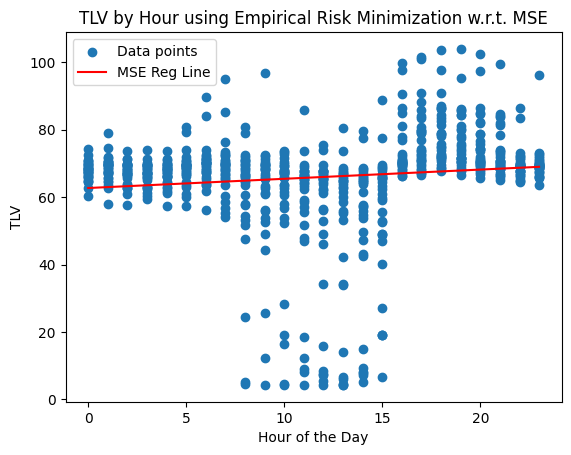

In [30]:
x_matrix = lin_reg(x, y, month, year)

#### KNN Regression

In [31]:
# Splitting data into test and training data
X_train, X_test, y_train, y_test = train_test_split(x_matrix, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

k = round(np.sqrt(len(x_matrix))) #letting k = square root of n
y_train = np.array(y_train)
y_pred = knn_predict(X_train, y_train, X_test, k=k) #KNN predictons for TLV
print("KNN TLV predictions:",y_pred)

KNN TLV predictions: [60.83879392 52.98264108 69.9118172  54.56372398 69.91922149 60.83879392
 77.47387883 71.92032342 77.47387883 76.12213864 54.56372398 70.41177776
 52.98264108 68.07353312 69.9118172  69.9118172  52.00637353 60.71177005
 72.6054791  66.79455544 56.73879831 50.45455417 60.71177005 54.56372398
 50.45455417 74.79408361 56.73879831 72.6054791  67.2067004  67.73408616
 67.21586587 69.91922149 68.07353312 69.9118172  68.07353312 52.00637353
 66.88979494 66.88979494 52.98264108 66.88979494 60.83879392 77.47387883
 67.73408616 67.2067004  69.91922149 76.12213864 67.2067004  72.6054791
 60.71177005 52.98264108 79.40668547 66.88979494 74.79408361 70.41177776
 60.83879392 68.07353312 68.07353312 69.91922149 69.91009889 69.91922149
 54.56372398 54.56372398 79.40668547 66.79455544 52.98264108 69.91009889
 66.88979494 67.21586587 79.40668547 67.21586587 60.83879392 77.47387883
 66.88979494 66.88979494 70.41177776 67.73408616 69.91922149 56.73879831
 52.98264108 66.79455544 67.734

RMSE for KNN: 13.883431600677795


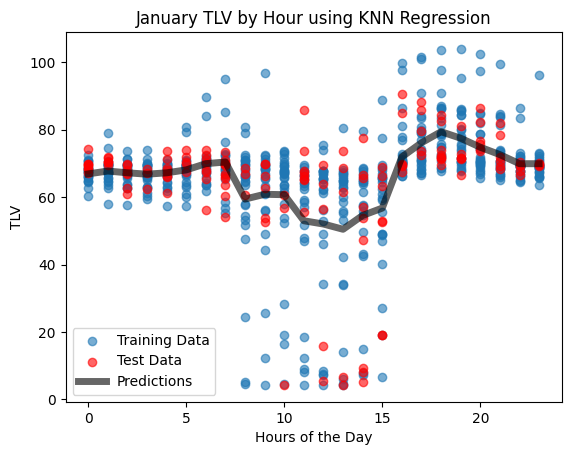

In [32]:
# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
reg_errors[year].loc[month,'KNN'] = rmse
print(f"RMSE for KNN: {rmse}") # Much lower than MSE regression!

# Sort the test data and corresponding predictions for smooth plotting
sorted_indices = np.argsort(X_test[:,1].flatten())
X_test_sorted = X_test[:,1].flatten()[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Training Data
plt.scatter(X_train[:,1], y_train, label="Training Data", alpha=0.6)
# Testing Data
plt.scatter(X_test[:,1], y_test, label="Test Data", color="red", alpha=0.6)
# Predicted regression
plt.plot(X_test_sorted, y_pred_sorted, label="Predictions", color="black", alpha=0.6, linewidth = 5)

# Plot settings
plt.legend()
plt.xlabel("Hours of the Day")
plt.ylabel("TLV")
plt.title("January TLV by Hour using KNN Regression")
plt.show()

#### Cluster + Linear Regression

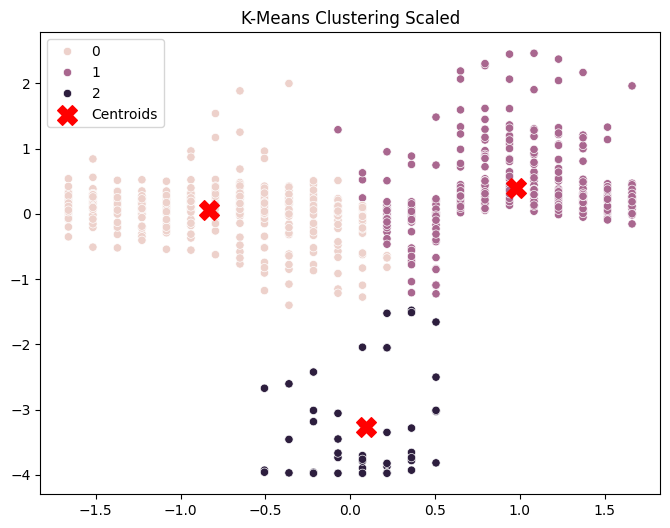

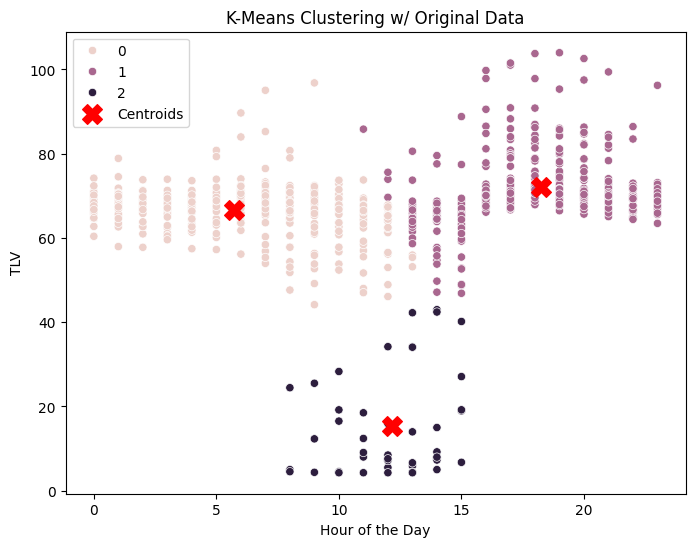

In [33]:
create_cluster_scatterplots(jan22_data_temporal_melted, create_clusters)

In [34]:
jan22_data_temporal_melted = create_clusters(jan22_data_temporal_melted)[0]
jan22_data_temporal_melted

,Hour of the Day,1,Value,Cluster
0,0,1,60.396590,0
1,1,1,62.631308,0
2,2,1,62.726845,0
3,3,1,62.852241,0
4,4,1,64.185014,0
...,...,...,...,...
739,19,31,81.149894,1
740,20,31,75.760548,1
741,21,31,83.913557,1
742,22,31,71.727782,1


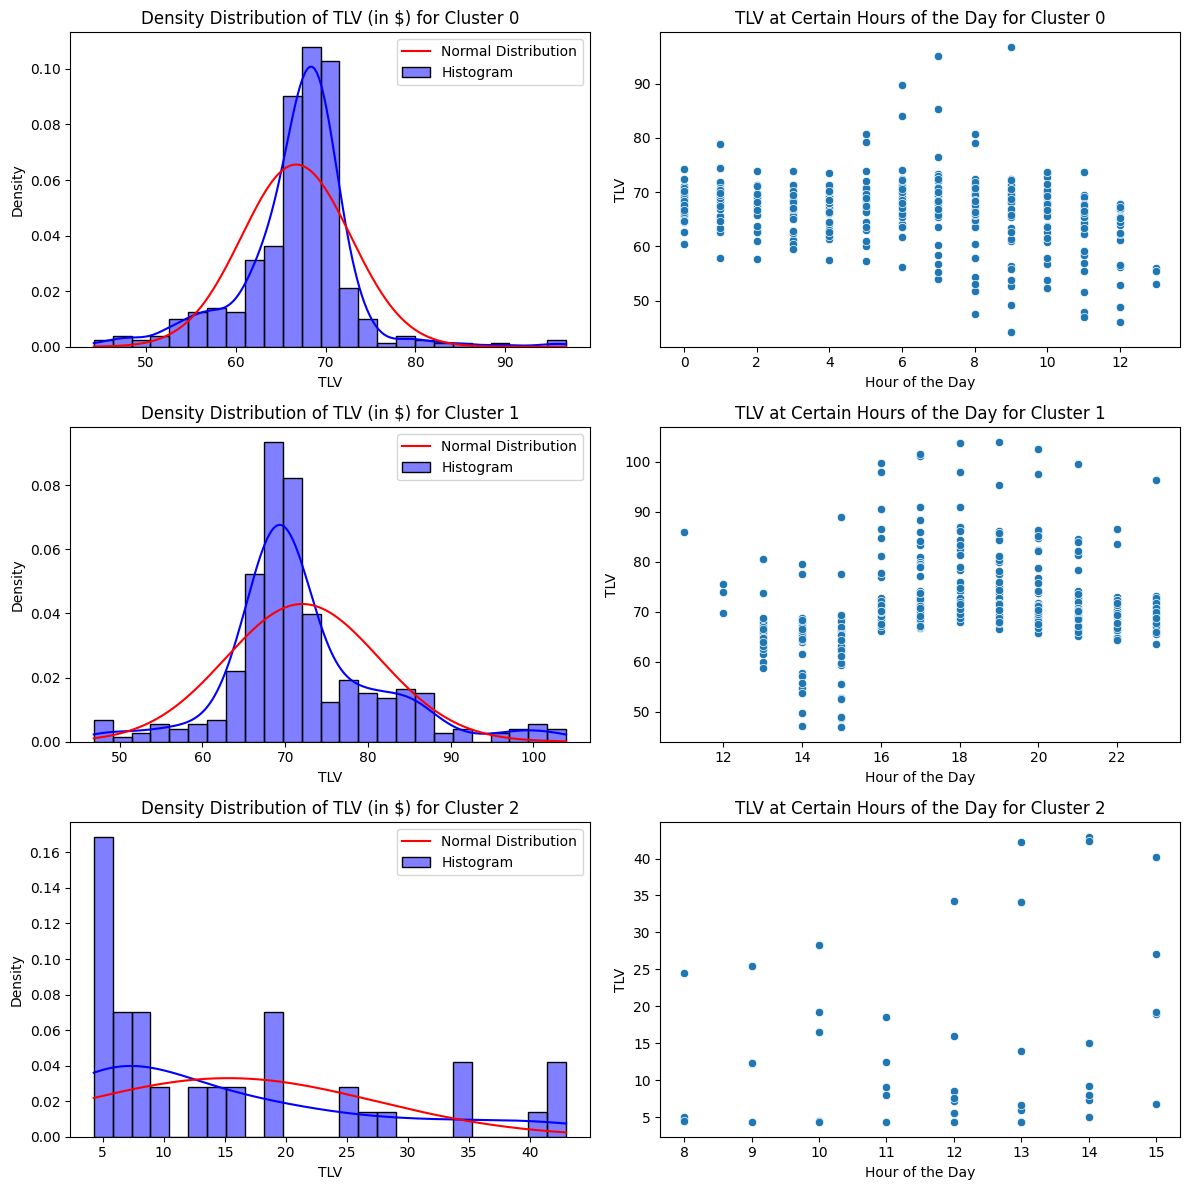

cluster weights:  {np.int32(0): array([69.07028705, -0.40965991]), np.int32(1): array([62.7122656 ,  0.51309183]), np.int32(2): array([-0.47949605,  1.29711868])}
cluster square loss risk:  7.86925943722729


In [35]:
analyze_cluster_dist(jan22_data_temporal_melted)
print("cluster weights: ", compute_MSE_weights(jan22_data_temporal_melted)) 
print("cluster square loss risk: ", compute_square_risk(jan22_data_temporal_melted, compute_MSE_weights))

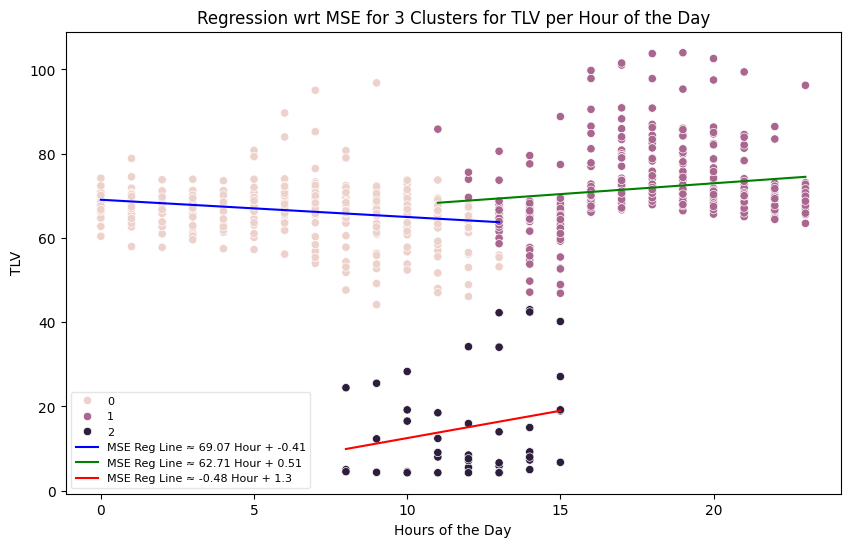

In [36]:
cluster_MSE_reg_graphs(jan22_data_temporal_melted, compute_MSE_weights)

In [40]:
# Risk for this type of pricing scheme:
risk = compute_square_risk(jan22_data_temporal_melted, compute_MSE_weights)
reg_errors[year].loc[month,'Linear+Cluster'] = risk

print("empirical risk: ", risk)

empirical risk:  7.86925943722729


#### Gaussian Basis Regression

In [41]:
# Parameters
mu = np.linspace(0, 23, 10) # Uses 10 mu's equally spaced out
sigma = (max(x) - min(x)) / 10 #using (max(x) - min(x))/(# of basis functions) for sigma


w = gaussian_weights(x, y, mu, sigma) #Optimal weight vectors given x and y in dataset

print("sigma: ", sigma)
print("weight vector: ", w)

sigma:  2.3
weight vector:  [55.97248795 34.9453724  48.21591586 38.13518684 37.86260969 27.31358323
 36.46019841 58.28162239 38.65004477 56.08006562]


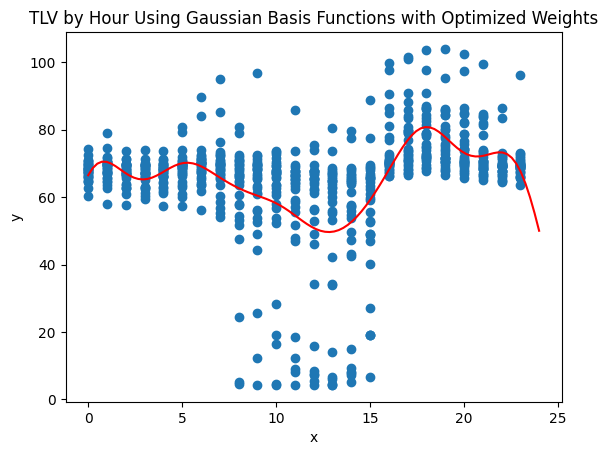

In [42]:
# Plotting H(x) prediction line on data
x_reg = np.linspace(0, 24, 100)
H= plot_h(x_reg, mu, w, sigma)

plt.plot(x_reg, H, color="red")
plt.scatter(x, y)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('TLV by Hour Using Gaussian Basis Functions with Optimized Weights')
plt.show()


In [43]:
# Calculating Risk
pred_y = H= plot_h(x, mu, w, sigma)
risk = np.sqrt(mean_squared_error(y, H))
reg_errors[year].loc[month,'Gaussian Basis'] = risk

print("risk w.r.t. RMSE: ", risk)

risk w.r.t. RMSE:  13.178841135371213


### 2021 January

In [44]:
month = "January"
year = "2021"

jan21_data = load_dataset(month, year)[2]
jan21_data_temporal_melted = load_dataset(month, year)[3]

x = load_dataset(month, year)[0]
y = load_dataset(month, year)[1]
jan21_data.head()

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
Hour of the Day,,,,,,,,,,,,,,,,,,,,,
0,283.499287,73.118222,158.206516,73.118222,272.899569,73.118222,78.376071,70.631037,68.143852,73.118222,...,79.720388,73.118222,65.663253,73.118222,404.540963,60.688883,65.663253,70.021243,48.266130,63.176068
1,70.631037,86.373635,93.494941,116.415209,79.775256,70.631037,73.118222,68.143852,65.663253,73.118222,...,73.118222,68.143852,63.176068,70.631037,60.688883,60.688883,65.663253,78.743198,58.201697,69.930889
2,70.631037,73.118222,90.579653,68.143852,90.515331,70.631037,73.118222,68.143852,65.663253,70.631037,...,73.118222,70.631037,60.688883,68.143852,60.688883,48.266130,65.663253,78.740250,65.663253,65.663253
3,68.143852,73.118222,81.851647,70.631037,90.515331,65.663253,70.631037,65.663253,65.663253,70.631037,...,70.631037,70.631037,60.688883,65.663253,50.746729,48.266130,65.663253,78.740136,63.176068,65.663253
4,70.631037,79.735547,96.397235,68.143852,80.573176,73.118222,73.118222,65.663253,65.663253,70.631037,...,73.118222,70.631037,60.688883,65.663253,50.746729,48.266130,74.401747,74.388468,65.663253,65.663253


In [45]:
# MSE per month per regression type dataframe
reg_errors[year] = pd.DataFrame(index=months, columns=reg_types)

#### Linear Regression

intercept = w[0]: 67.04627674700161
slope = w[1]: 2.9163832586098253
RMSE using linear regression: 98.5837619896307


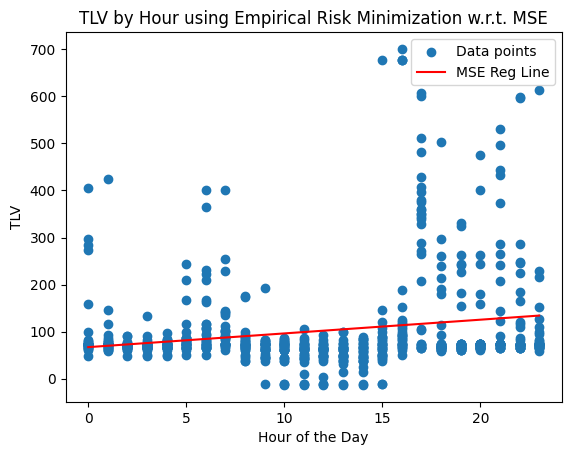

In [46]:
x_matrix = lin_reg(x, y, month, year)

#### KNN Regression

In [47]:
# Splitting data into test and training data
X_train, X_test, y_train, y_test = train_test_split(x_matrix, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

k = round(np.sqrt(len(x_matrix))) #letting k = square root of n
y_train = np.array(y_train)
y_pred = knn_predict(X_train, y_train, X_test, k=k) #KNN predictons for TLV
print("KNN TLV predictions:",y_pred)

KNN TLV predictions: [ 63.62926669  53.67467789 128.46717095  55.40823994 124.85125172
  63.62926669 114.97228188 178.62804561 114.97228188 273.532811
  55.40823994 121.16941278  53.67467789  89.24816988 128.46717095
 128.46717095  55.05057127  56.90329036 160.2762168   72.00796723
  83.71744358  50.2558883   56.90329036  55.40823994  50.2558883
 117.67775784  83.71744358 160.2762168   71.99035871  89.08908328
  71.96275906 124.85125172  89.24816988 128.46717095  89.24816988
  55.05057127 115.31587684 115.31587684  53.67467789 115.31587684
  63.62926669 114.97228188  89.08908328  71.99035871 124.85125172
 273.532811    71.99035871 160.2762168   56.90329036  53.67467789
 142.87168205 115.31587684 117.67775784 121.16941278  63.62926669
  89.24816988  89.24816988 124.85125172 111.02278299 124.85125172
  55.40823994  55.40823994 142.87168205  72.00796723  53.67467789
 111.02278299 115.31587684  71.96275906 142.87168205  71.96275906
  63.62926669 114.97228188 115.31587684 115.31587684 121.1

RMSE for KNN: 77.27834947272599


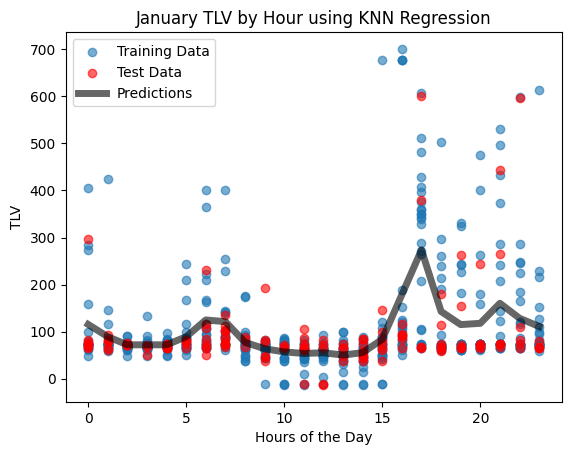

In [48]:
# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
reg_errors[year].loc[month,'KNN'] = rmse
print(f"RMSE for KNN: {rmse}") # Much lower than MSE regression!

# Sort the test data and corresponding predictions for smooth plotting
sorted_indices = np.argsort(X_test[:,1].flatten())
X_test_sorted = X_test[:,1].flatten()[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Training Data
plt.scatter(X_train[:,1], y_train, label="Training Data", alpha=0.6)
# Testing Data
plt.scatter(X_test[:,1], y_test, label="Test Data", color="red", alpha=0.6)
# Predicted regression
plt.plot(X_test_sorted, y_pred_sorted, label="Predictions", color="black", alpha=0.6, linewidth = 5)

# Plot settings
plt.legend()
plt.xlabel("Hours of the Day")
plt.ylabel("TLV")
plt.title("January TLV by Hour using KNN Regression")
plt.show()

#### Cluster + Linear Regression

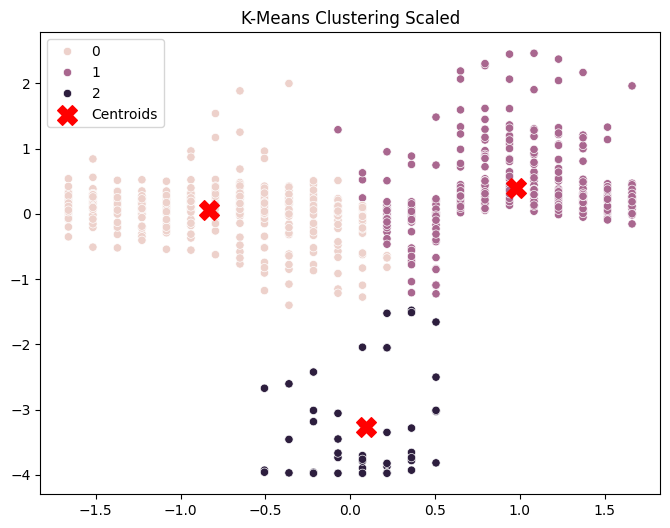

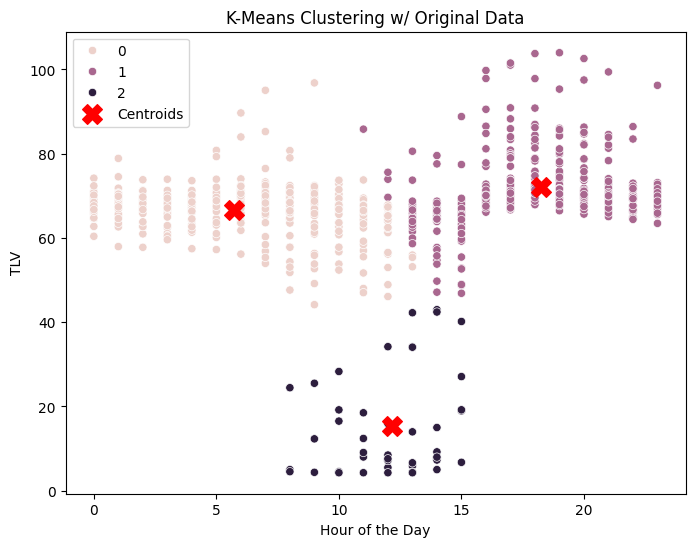

In [49]:
create_cluster_scatterplots(jan22_data_temporal_melted, create_clusters)

In [50]:
jan21_data_temporal_melted = create_clusters(jan21_data_temporal_melted)[0]
jan21_data_temporal_melted

,Hour of the Day,1,Value,Cluster
0,0,1,283.499287,1
1,1,1,70.631037,1
2,2,1,70.631037,1
3,3,1,68.143852,1
4,4,1,70.631037,1
...,...,...,...,...
739,19,31,65.663253,2
740,20,31,65.663253,2
741,21,31,432.304007,0
742,22,31,70.631037,2


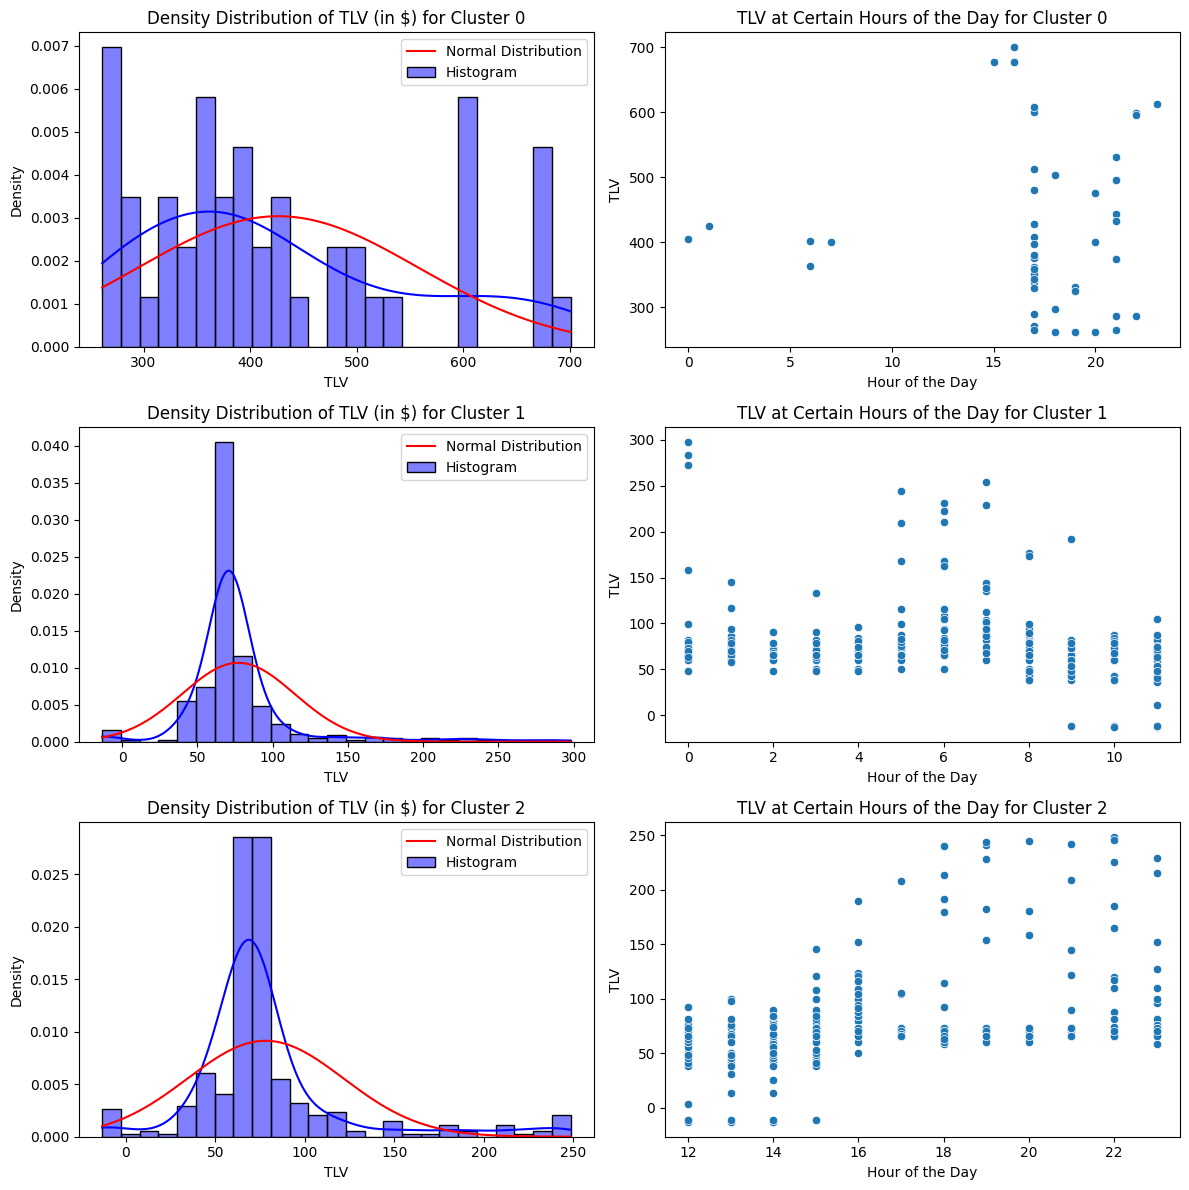

cluster weights:  {np.int32(0): array([4.23227330e+02, 1.90720772e-01]), np.int32(1): array([87.4672322 , -1.85770937]), np.int32(2): array([5.58577322, 4.1694211 ])}
cluster square loss risk:  50.206276332993724


In [51]:
analyze_cluster_dist(jan21_data_temporal_melted)
print("cluster weights: ", compute_MSE_weights(jan21_data_temporal_melted)) 
print("cluster square loss risk: ", compute_square_risk(jan21_data_temporal_melted, compute_MSE_weights))

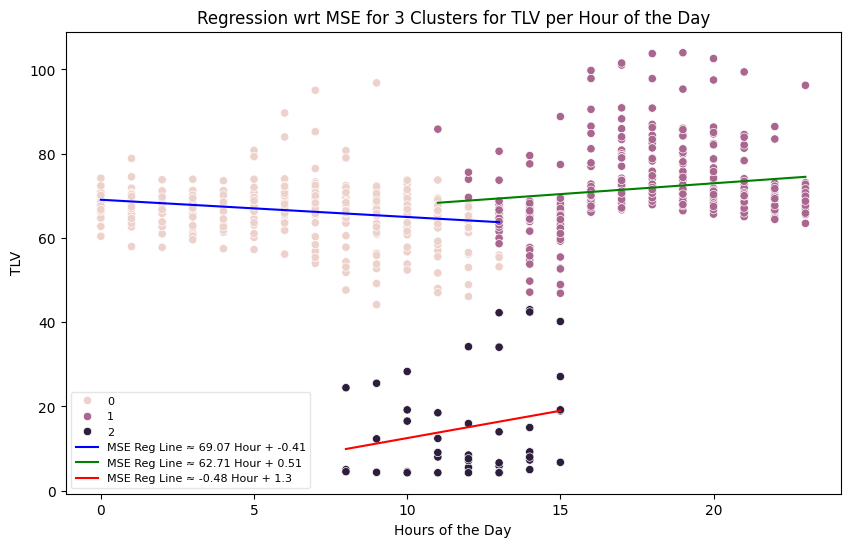

In [52]:
cluster_MSE_reg_graphs(jan22_data_temporal_melted, compute_MSE_weights)

In [54]:
# Risk for this type of pricing scheme:
risk = compute_square_risk(jan21_data_temporal_melted, compute_MSE_weights)
reg_errors[year].loc[month,'Linear+Cluster'] = risk

print("empirical risk: ", risk)

empirical risk:  50.206276332993724


#### Gaussian Basis Regression

In [55]:
# Parameters
mu = np.linspace(0, 23, 10) # Uses 10 mu's equally spaced out
sigma = (max(x) - min(x)) / 10 #using (max(x) - min(x))/(# of basis functions) for sigma


w = gaussian_weights(x, y, mu, sigma) #Optimal weight vectors given x and y in dataset

print("sigma: ", sigma)
print("weight vector: ", w)

sigma:  2.3
weight vector:  [102.3868342    5.67193047  85.92557173  49.57499025  48.54824354
  -8.34946469 102.94382065 129.151486    45.05792542 115.9423652 ]


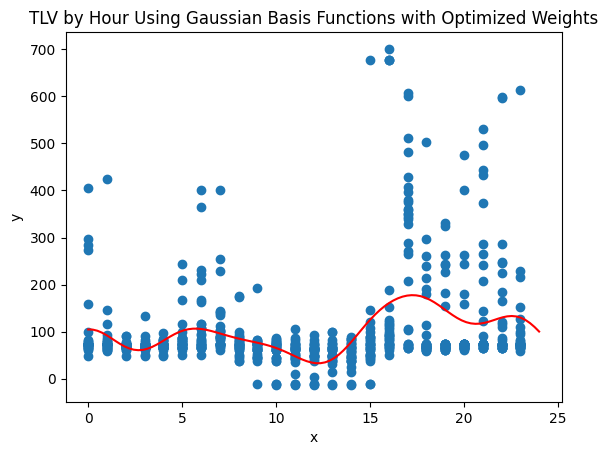

In [56]:
# Plotting H(x) prediction line on data
x_reg = np.linspace(0, 24, 100)
H= plot_h(x_reg, mu, w, sigma)

plt.plot(x_reg, H, color="red")
plt.scatter(x, y)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('TLV by Hour Using Gaussian Basis Functions with Optimized Weights')
plt.show()


In [57]:
# Calculating Risk
pred_y = H= plot_h(x, mu, w, sigma)
risk = np.sqrt(mean_squared_error(y, H))
reg_errors[year].loc[month,'Gaussian Basis'] = risk

print("risk w.r.t. RMSE: ", risk)

risk w.r.t. RMSE:  92.7203721650228


### 2019 January

In [58]:
month = "January"
year = "2019"

jan19_data = load_dataset(month, year)[2]
jan19_data_temporal_melted = load_dataset(month, year)[3]

x = load_dataset(month, year)[0]
y = load_dataset(month, year)[1]
jan19_data.head()

,1,2,3,4,5,6,7,8,9,10,...,22,23,24,25,26,27,28,29,30,31
Hour of the Day,,,,,,,,,,,,,,,,,,,,,
0,85.765156,79.962052,75.734951,85.076818,69.043625,68.258275,67.877158,70.874931,68.514614,54.424554,...,71.192332,71.451471,65.533749,65.921008,64.085153,77.629714,75.479298,65.082823,66.421715,67.679445
1,81.508642,77.494906,74.240406,79.813187,66.637924,67.784790,64.856029,67.989943,65.281301,50.894941,...,69.200835,67.714546,64.753111,63.594185,60.831874,73.326999,74.951517,61.311111,61.837121,65.125919
2,76.688742,75.573422,70.843606,78.134798,66.548249,65.569560,64.848399,62.344548,62.079956,47.782008,...,64.338518,66.349767,62.310281,61.939708,60.008594,70.753293,72.348839,61.096697,60.408746,62.569668
3,73.656512,73.349084,70.560988,76.330656,66.518375,65.290911,64.869171,62.030996,62.064369,47.845246,...,66.406064,67.191960,62.384429,62.656750,60.589223,71.881212,71.109851,61.575754,60.504838,62.364358
4,74.043427,77.371774,74.044359,81.598522,66.682761,64.726804,68.034737,71.061293,67.206802,54.137477,...,69.259374,68.816099,65.288144,64.650541,66.942759,69.803202,72.365158,67.461427,67.168800,69.097337


In [59]:
# MSE per month per regression type dataframe
reg_errors[year] = pd.DataFrame(index=months, columns=reg_types)

#### Linear Regression

intercept = w[0]: 46.46645554264178
slope = w[1]: 4.752816260643356
RMSE using linear regression: 104.07212772468998


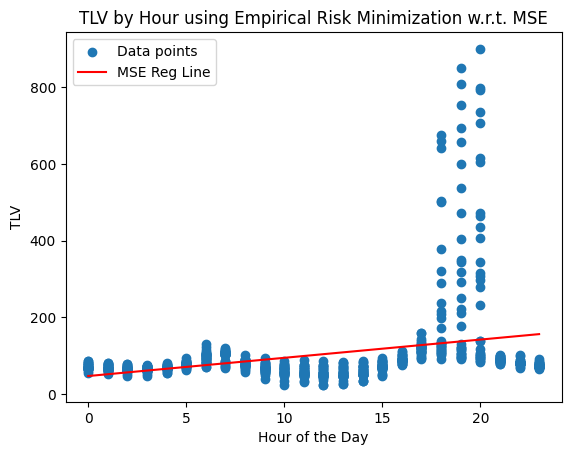

In [60]:
x_matrix = lin_reg(x, y, month, year)

#### KNN Regression

In [61]:
# Splitting data into test and training data
X_train, X_test, y_train, y_test = train_test_split(x_matrix, y, test_size=0.2, random_state=42)
X_train, X_test, y_train, y_test

k = round(np.sqrt(len(x_matrix))) #letting k = square root of n
y_train = np.array(y_train)
y_pred = knn_predict(X_train, y_train, X_test, k=k) #KNN predictons for TLV
print("KNN TLV predictions:",y_pred)

KNN TLV predictions: [ 64.80280585  58.94533833  81.71293919  60.25068097  95.49198138
  64.80280585 265.95096636  90.14623922 265.95096636 117.67249418
  60.25068097  93.08341941  58.94533833  75.37763438  81.71293919
  81.71293919  52.74169888  60.1058637   88.84409868  64.77709668
  70.36115143  54.2926049   60.1058637   60.25068097  54.2926049
 330.2154289   70.36115143  88.84409868  68.39214449  66.80256617
  65.75891797  95.49198138  75.37763438  81.71293919  75.37763438
  52.74169888  69.00055169  69.00055169  58.94533833  69.00055169
  64.80280585 265.95096636  66.80256617  68.39214449  95.49198138
 117.67249418  68.39214449  88.84409868  60.1058637   58.94533833
 233.35409576  69.00055169 330.2154289   93.08341941  64.80280585
  75.37763438  75.37763438  95.49198138  74.50361527  95.49198138
  60.25068097  60.25068097 233.35409576  64.77709668  58.94533833
  74.50361527  69.00055169  65.75891797 233.35409576  65.75891797
  64.80280585 265.95096636  69.00055169  69.00055169  93

RSE for KNN: 95.26625462179646


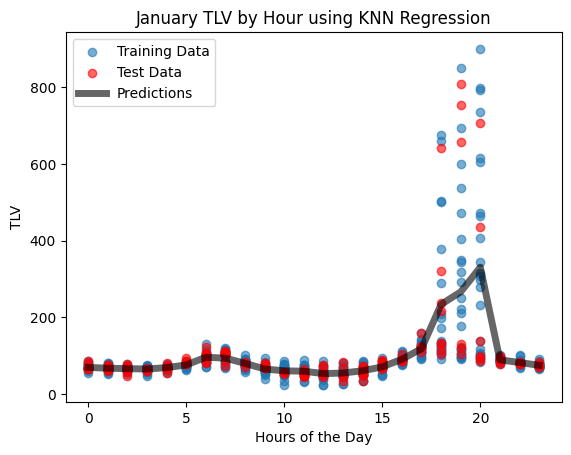

In [62]:
# Evaluate the model
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
reg_errors[year].loc[month,'KNN'] = rmse
print(f"RSE for KNN: {rmse}") # Much lower than MSE regression!

# Sort the test data and corresponding predictions for smooth plotting
sorted_indices = np.argsort(X_test[:,1].flatten())
X_test_sorted = X_test[:,1].flatten()[sorted_indices]
y_pred_sorted = y_pred[sorted_indices]

# Training Data
plt.scatter(X_train[:,1], y_train, label="Training Data", alpha=0.6)
# Testing Data
plt.scatter(X_test[:,1], y_test, label="Test Data", color="red", alpha=0.6)
# Predicted regression
plt.plot(X_test_sorted, y_pred_sorted, label="Predictions", color="black", alpha=0.6, linewidth = 5)

# Plot settings
plt.legend()
plt.xlabel("Hours of the Day")
plt.ylabel("TLV")
plt.title("January TLV by Hour using KNN Regression")
plt.show()

#### Cluster + Linear Regression

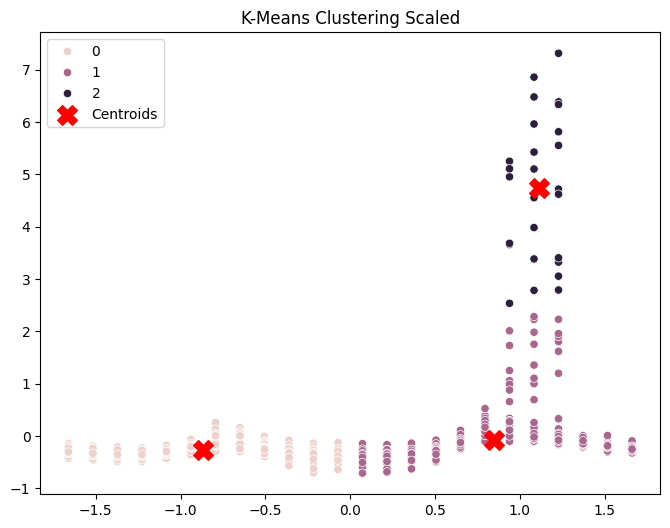

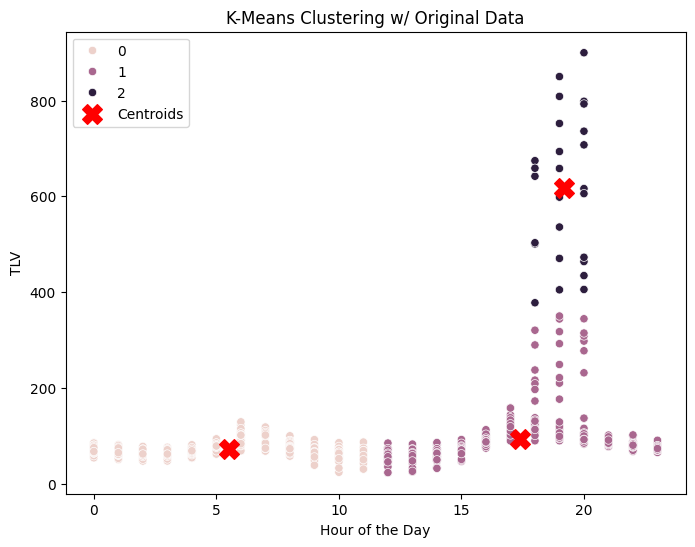

In [63]:
create_cluster_scatterplots(jan19_data_temporal_melted, create_clusters)

In [64]:
jan19_data_temporal_melted = create_clusters(jan19_data_temporal_melted)[0]
jan19_data_temporal_melted

,Hour of the Day,1,Value,Cluster
0,0,1,85.765156,0
1,1,1,81.508642,0
2,2,1,76.688742,0
3,3,1,73.656512,0
4,4,1,74.043427,0
...,...,...,...,...
739,19,31,658.244086,2
740,20,31,707.515026,2
741,21,31,91.390210,1
742,22,31,80.784788,1


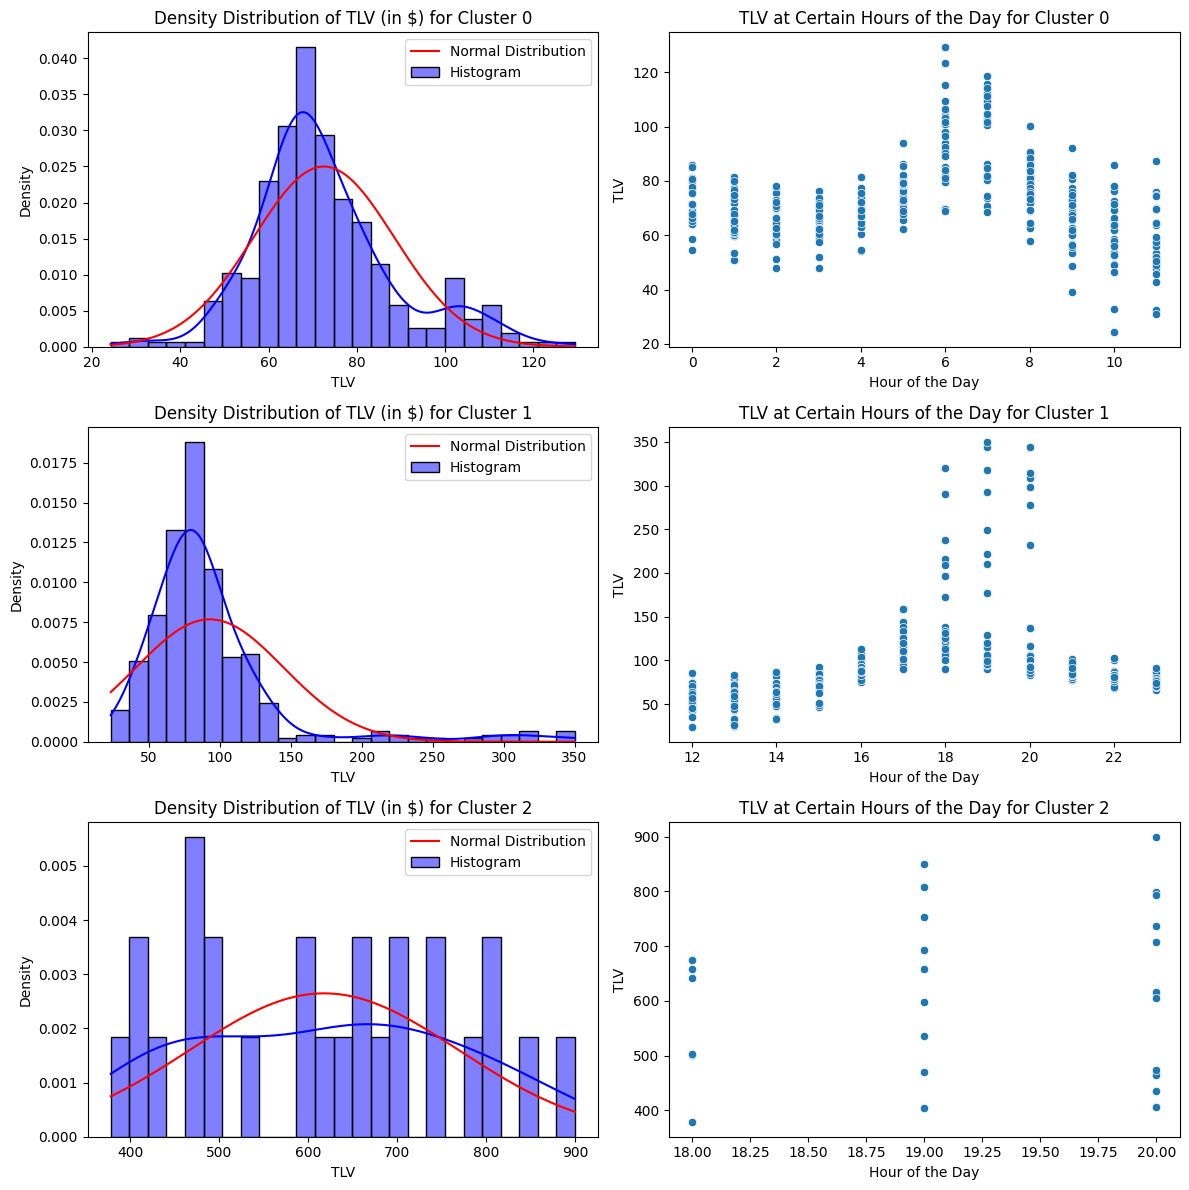

cluster weights:  {np.int32(0): array([ 7.27830118e+01, -4.77650268e-02]), np.int32(1): array([19.40282458,  4.23906307]), np.int32(2): array([34.43227474, 30.39871968])}
cluster square loss risk:  44.92571351851531


In [65]:
analyze_cluster_dist(jan19_data_temporal_melted)
print("cluster weights: ", compute_MSE_weights(jan19_data_temporal_melted)) 
print("cluster square loss risk: ", compute_square_risk(jan19_data_temporal_melted, compute_MSE_weights))

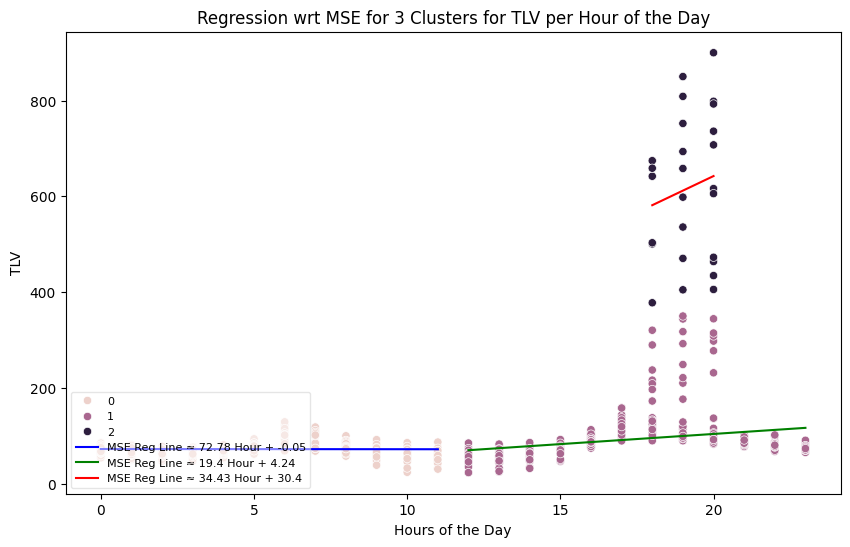

In [66]:
cluster_MSE_reg_graphs(jan19_data_temporal_melted, compute_MSE_weights)

In [68]:
# Risk for this type of pricing scheme:
risk = compute_square_risk(jan19_data_temporal_melted, compute_MSE_weights)
reg_errors[year].loc[month,'Linear+Cluster'] = risk

print("empirical risk: ", risk)

empirical risk:  44.92571351851531


#### Gaussian Basis Regression

In [69]:
# Parameters
mu = np.linspace(0, 23, 10) # Uses 10 mu's equally spaced out
sigma = (max(x) - min(x)) / 10 #using (max(x) - min(x))/(# of basis functions) for sigma


w = gaussian_weights(x, y, mu, sigma) #Optimal weight vectors given x and y in dataset

print("sigma: ", sigma)
print("weight vector: ", w)

sigma:  2.3
weight vector:  [ 60.11102726  28.74749758  52.48697416  72.11737307  10.44924662
  67.24103626 -19.95159466 186.48270414 180.80979926 -25.93515135]


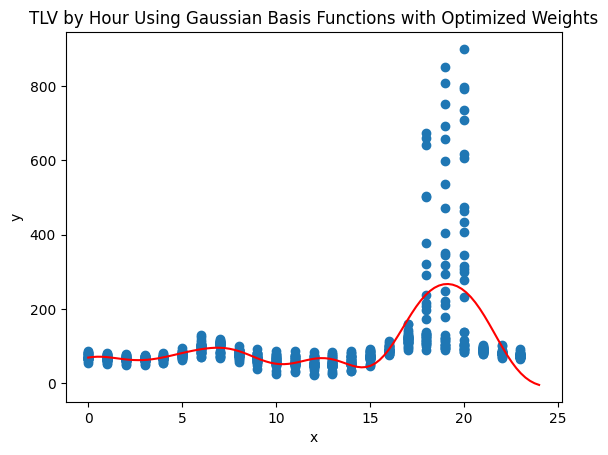

In [70]:
# Plotting H(x) prediction line on data
x_reg = np.linspace(0, 24, 100)
H= plot_h(x_reg, mu, w, sigma)

plt.plot(x_reg, H, color="red")
plt.scatter(x, y)

# Add labels and legend
plt.xlabel('x')
plt.ylabel('y')
plt.title('TLV by Hour Using Gaussian Basis Functions with Optimized Weights')
plt.show()


In [71]:
# Calculating Risk
pred_y = H= plot_h(x, mu, w, sigma)
risk = np.sqrt(mean_squared_error(y, H))
reg_errors[year].loc[month,'Gaussian Basis'] = risk

print("risk w.r.t. RMSE: ", risk)

risk w.r.t. RMSE:  86.61694544016835


In [72]:
reg_errors

{'2024':               Linear        KNN Linear+Cluster Gaussian Basis
 January    67.085515  29.332051      27.108538      31.911611
 February         NaN        NaN            NaN            NaN
 March            NaN        NaN            NaN            NaN
 April            NaN        NaN            NaN            NaN
 May              NaN        NaN            NaN            NaN
 June             NaN        NaN            NaN            NaN
 July             NaN        NaN            NaN            NaN
 August           NaN        NaN            NaN            NaN
 September        NaN        NaN            NaN            NaN
 October          NaN        NaN            NaN            NaN
 November         NaN        NaN            NaN            NaN
 December         NaN        NaN            NaN            NaN,
 '2022':               Linear        KNN Linear+Cluster Gaussian Basis
 January    15.367912  13.883432       7.869259      13.178841
 February         NaN        NaN      

---

### Looking at the data combined

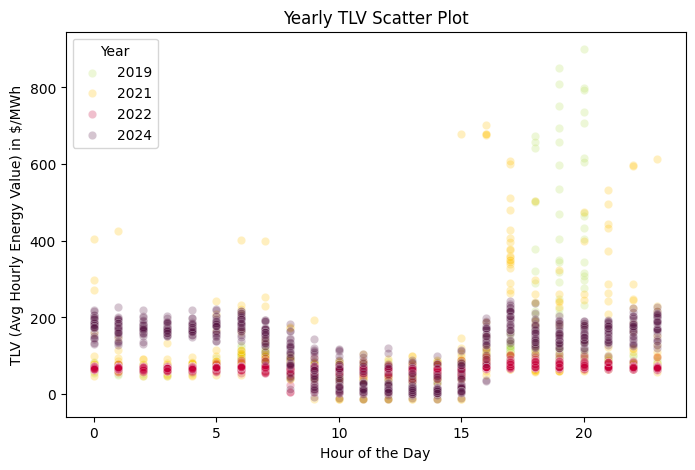

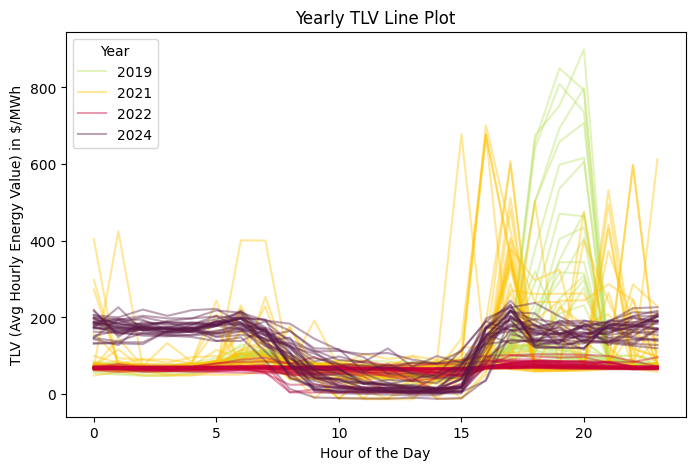

In [73]:
years = ["2019", "2021", "2022", "2024"]
# palette = ["red", "green", "blue", "purple"] 
palette = ["#bae161", "#FFC300", "#C70039", "#581845"] 
palette_dict = {"2019": "#bae161", "2021": "#FFC300", "2022": "#C70039", "2024": "#581845"}

yearly_data = [jan19_data, jan21_data, jan22_data, jan24_data]  # DataFrames for each year

# --- Scatter Plot ---
plt.figure(figsize=(8, 5))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.scatterplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.25)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Scatter Plot")
plt.legend(title="Year", loc="upper left")
plt.show()

# --- Line Plot ---
plt.figure(figsize=(8, 5))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


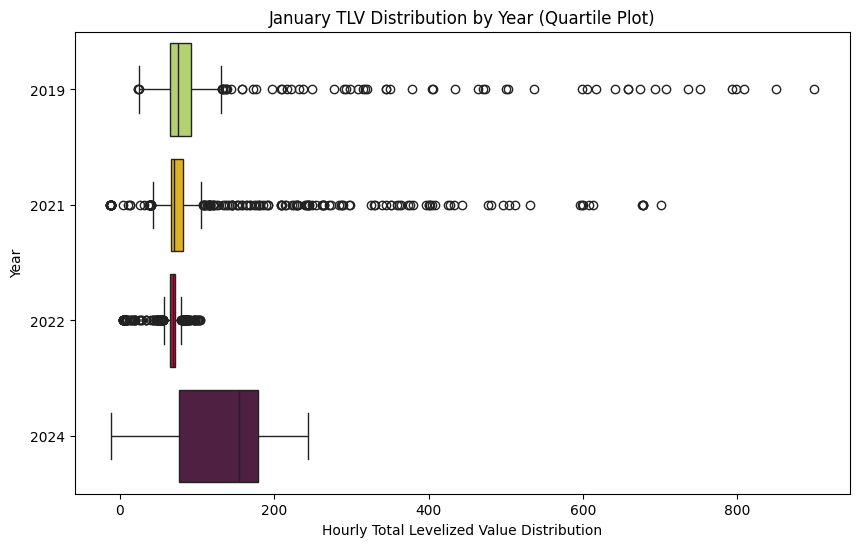

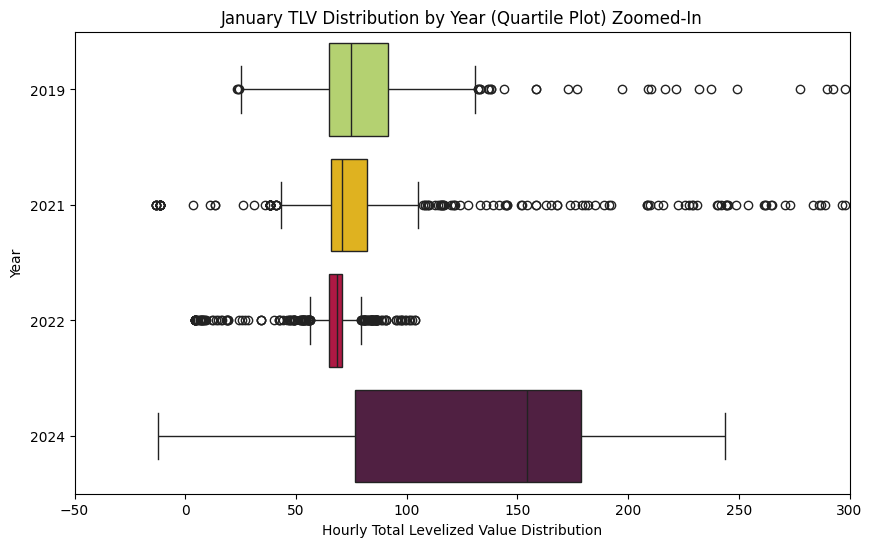

In [74]:
# Add a "Year" column to each DataFrame
jan19_data_temporal_melted["Year"] = "2019"
jan21_data_temporal_melted["Year"] = "2021"
jan22_data_temporal_melted["Year"] = "2022"
jan24_data_temporal_melted["Year"] = "2024"

# Combine both datasets into one
combined_data = pd.concat([jan19_data_temporal_melted, jan21_data_temporal_melted, jan22_data_temporal_melted, jan24_data_temporal_melted])

plt.figure(figsize=(10, 6))

# Create stacked horizontal box plots (assign hue for color separation)
sns.boxplot(x="Value", y="Year", data=combined_data, hue="Year", palette=palette_dict, legend=False)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Year")
plt.title("January TLV Distribution by Year (Quartile Plot)")


plt.show()

plt.figure(figsize=(10, 6))
# Create stacked horizontal box plots (assign hue for color separation)
sns.boxplot(x="Value", y="Year", data=combined_data, hue="Year", palette=palette_dict, legend=False)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Year")
plt.title("January TLV Distribution by Year (Quartile Plot) Zoomed-In")
plt.xlim(-50, 300)

plt.show()


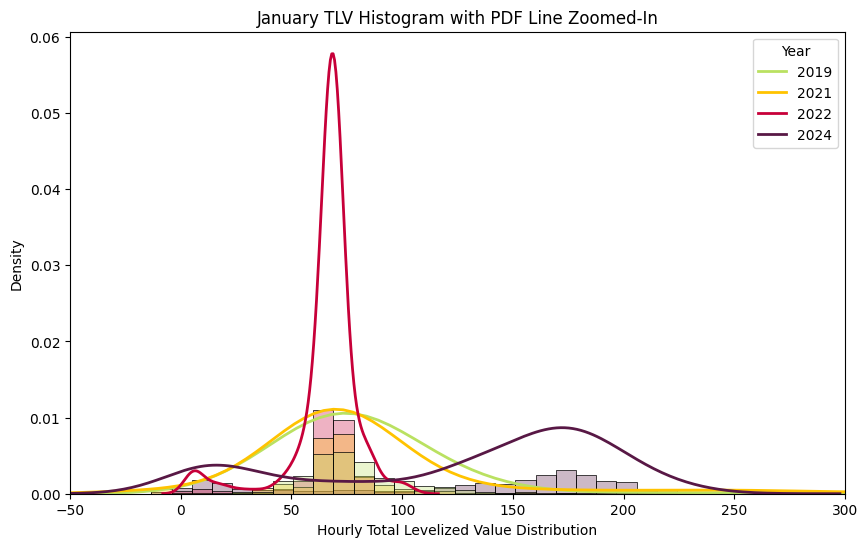

In [75]:
plt.figure(figsize=(10, 6))

# Create histogram with transparency
sns.histplot(data=combined_data, x="Value", hue="Year", bins=100, stat="density", 
             palette = palette_dict, 
             alpha=0.3)

# Overlay PDF line using KDE plot with explicit labels
yearly_temporal_data = [jan19_data_temporal_melted, jan21_data_temporal_melted, jan22_data_temporal_melted, jan24_data_temporal_melted]
for i, data in enumerate(yearly_temporal_data):  # Iterate over datasets
    year = years[i]
    color = palette[i]
    subset = combined_data[combined_data["Year"] == year]
    sns.kdeplot(x=subset["Value"], color=color, linewidth=2, label=year)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Density")
plt.title("January TLV Histogram with PDF Line Zoomed-In")
plt.xlim(-50, 300)
plt.legend(title="Year")
plt.show()


In [76]:
# Initialize DataFrame for basic stats
yearly_distr = pd.DataFrame()

# List of datasets per year
years = ["2019", "2021", "2022", "2024"]

for i, data in enumerate(yearly_temporal_data):  # Iterate over datasets
    year = years[i]
    data_values = data["Value"].dropna()

    # Compute mean (μ) and standard deviation (σ)
    mu = np.mean(data_values)
    sigma = np.std(data_values, ddof=1)  # Sample std dev

    # Compute IQR for outlier detection
    Q1 = np.percentile(data_values, 25)
    Q3 = np.percentile(data_values, 75)
    IQR = Q3 - Q1

    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Count outliers
    outliers = data_values[(data_values < lower_bound) | (data_values > upper_bound)]
    num_outliers = len(outliers)

    # Store values in DataFrame
    yearly_distr.loc[year, "mean"] = mu
    yearly_distr.loc[year, "standard deviation"] = sigma
    yearly_distr.loc[year, "outlier count"] = num_outliers

# Calculating Marginal Difference Percentage
yearly_distr["% change in mean"] = yearly_distr["mean"].pct_change() * 100

print("Descriptive Stats: ")
yearly_distr

Descriptive Stats: 


,mean,standard deviation,outlier count,% change in mean
2019,101.123843,109.221995,61.0,NaN
2021,100.584684,100.697231,162.0,-0.533166
2022,65.842350,15.494421,148.0,-34.540382
2024,128.780858,67.321902,0.0,95.589706


##### Observations:
- Spread of distribution in general getting smaller as years increase (except for 2022, which has the smallest standard deviation)
- Outliers less spread out as years increases. Could be because of temporal/random circumstances that year, or lack of good distribution infrastructure in the past, causing prices to be less stable. We will compare year by year data:

---

### Yearly regressional model for January

Dependent Variable: TLV (fixed + variable)

Predictors:
- year
- hour of the day
- day of January


In [77]:
# Combining Yearly Data
jan_yearly_data = combined_data[["Hour of the Day", "1", "Year", "Value"]].rename(columns={"Hour of the Day": "Hour_of_the_Day", "1": "Day_of_Month"})

jan_yearly_data["Hour_of_the_Day"] = jan_yearly_data["Hour_of_the_Day"].astype("int")
jan_yearly_data["Day_of_Month"] = jan_yearly_data["Day_of_Month"].astype("int")
jan_yearly_data["Value"] = jan_yearly_data["Value"].astype("float")
jan_yearly_data["Year"] = jan_yearly_data["Year"].astype("category")

jan_yearly_data["hour_sin"] = np.sin(2 * np.pi * jan_yearly_data["Hour_of_the_Day"] / 24)
jan_yearly_data["hour_cos"] = np.cos(2 * np.pi * jan_yearly_data["Hour_of_the_Day"] / 24)

jan_yearly_data.head()

,Hour_of_the_Day,Day_of_Month,Year,Value,hour_sin,hour_cos
0,0,1,2019,85.765156,0.000000,1.000000
1,1,1,2019,81.508642,0.258819,0.965926
2,2,1,2019,76.688742,0.500000,0.866025
3,3,1,2019,73.656512,0.707107,0.707107
4,4,1,2019,74.043427,0.866025,0.500000


In [78]:
# Define response variable
response = 'Value'

# Define covariates
covariates = ["Day_of_Month", "Year", "hour_sin", "hour_cos"]


model_formula = f'{response} ~ {" + ".join(covariates)}'
print(f"Model Formula: {model_formula}")

# Splitting Data into training and testing sets
train_data, test_data = train_test_split(jan_yearly_data, test_size=0.2, random_state=42)

# Training Model on Training Data
full_model = smf.ols(model_formula, data=train_data).fit()

# Making Predictions on Test Set
y_test = test_data[response]  # Actual values
y_pred = full_model.predict(test_data)  # Predicted values

# Computing RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(full_model.summary())
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")


Model Formula: Value ~ Day_of_Month + Year + hour_sin + hour_cos
                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.170
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     81.23
Date:                Fri, 04 Apr 2025   Prob (F-statistic):           1.15e-92
Time:                        14:48:58   Log-Likelihood:                -13702.
No. Observations:                2380   AIC:                         2.742e+04
Df Residuals:                    2373   BIC:                         2.746e+04
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------

#### Trying Polynomial Regression

In [79]:
year_mapping = {2019: 0, 2021: 1, 2022: 2, 2024: 3}
jan_yearly_data["Scaled_Year"] = jan_yearly_data["Year"].astype(int).replace(year_mapping)
jan_yearly_data["Scaled_Year^2"] = jan_yearly_data["Scaled_Year"] **2

jan_yearly_data.head()

,Hour_of_the_Day,Day_of_Month,Year,Value,hour_sin,hour_cos,Scaled_Year,Scaled_Year^2
0,0,1,2019,85.765156,0.000000,1.000000,0,0
1,1,1,2019,81.508642,0.258819,0.965926,0,0
2,2,1,2019,76.688742,0.500000,0.866025,0,0
3,3,1,2019,73.656512,0.707107,0.707107,0,0
4,4,1,2019,74.043427,0.866025,0.500000,0,0


In [80]:
response = 'Value'

covariates = ["Day_of_Month", "Scaled_Year", "hour_sin", "hour_cos"]

X = jan_yearly_data[covariates] 
y = jan_yearly_data[response]

# Add second degree polynomial terms for each covariate
poly = PolynomialFeatures(degree=2, include_bias=False)  # Create 2nd-degree polynomial terms
X_poly = poly.fit_transform(X)  # Transform features

# Split data into test and training sets
X_train, X_test, y_train, y_test = train_test_split(X_poly, y, test_size=0.2, random_state=42)

# Training Polynomial Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# Making Predictions
y_pred = model.predict(X_test)

# Evaluating Model Performance
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# Display Model Coefficients
feature_names = poly.get_feature_names_out(X.columns)
model_coefficients = pd.DataFrame({"Feature": feature_names, "Coefficient": model.coef_})

print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(model_coefficients)

X_train_const = sm.add_constant(X_train)  # Add intercept term (like OLS)
model_sm = sm.OLS(y_train, X_train_const).fit()

# Print the full summary
print(model_sm.summary())

Root Mean Squared Error (RMSE): 77.40
                     Feature  Coefficient
0               Day_of_Month     0.386148
1                Scaled_Year   -32.134944
2                   hour_sin   -44.982038
3                   hour_cos    -4.962191
4             Day_of_Month^2     0.011854
5   Day_of_Month Scaled_Year    -0.647341
6      Day_of_Month hour_sin    -0.502830
7      Day_of_Month hour_cos     0.702256
8              Scaled_Year^2    15.886855
9       Scaled_Year hour_sin    20.290302
10      Scaled_Year hour_cos    15.150292
11                hour_sin^2    32.056858
12         hour_sin hour_cos   -14.470556
13                hour_cos^2   -32.056858
                            OLS Regression Results                            
Dep. Variable:                  Value   R-squared:                       0.281
Model:                            OLS   Adj. R-squared:                  0.277
Method:                 Least Squares   F-statistic:                     71.14
Date:           

#### 2019 to 2021

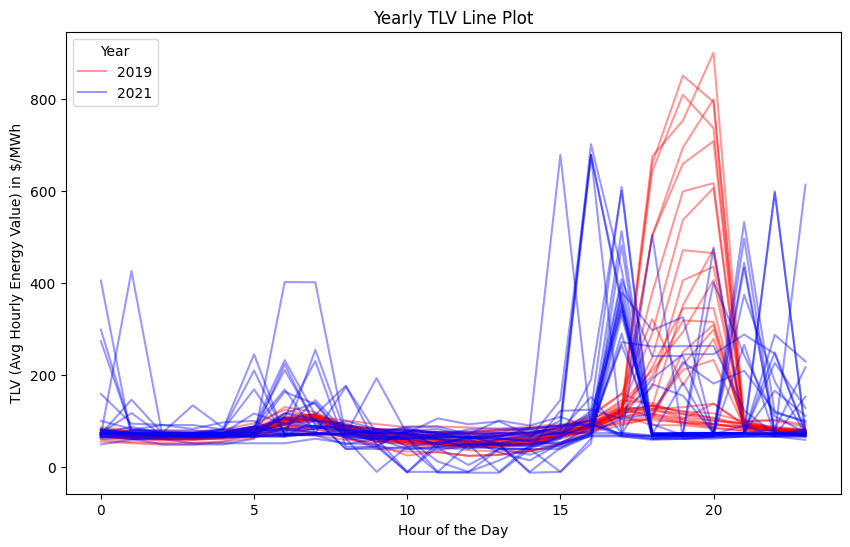

In [81]:
years = ["2019", "2021"]
palette = ["red", "blue"] 

yearly_data = [jan19_data, jan21_data]  # DataFrames for each year

plt.figure(figsize=(10, 6))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


##### Looking at graphs without the outliers

In [ ]:
jan19_data_temporal_melted

In [ ]:
# Add a "Year" column to each DataFrame
jan19_data_temporal_melted["Year"] = "2019"
jan21_data_temporal_melted["Year"] = "2021"

# Combine both datasets into one
combined_data = pd.concat([jan19_data_temporal_melted, jan21_data_temporal_melted])

plt.figure(figsize=(10, 6))

# Create stacked horizontal box plots (assign hue for color separation)
sns.boxplot(x="Value", y="Year", data=combined_data, hue="Year", palette={"2019": "red", "2021": "blue"}, legend=False)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Year")
plt.title("January TLV Distribution by Year (Quartile Plot)")

plt.xlim(-50, 200)
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Add a "Year" column to each DataFrame
jan19_data_temporal_melted["Year"] = "2019"
jan21_data_temporal_melted["Year"] = "2021"

# Combine both datasets into one
combined_data = pd.concat([jan19_data_temporal_melted, jan21_data_temporal_melted])

plt.figure(figsize=(10, 6))

# Create histogram with transparency
sns.histplot(data=combined_data, x="Value", hue="Year", bins=100, stat="density", palette={"2019": "red", "2021": "blue"}, alpha=0.3)

# Overlay PDF line using KDE plot with explicit labels
for year, color in zip(["2019", "2021"], ["red", "blue"]):
    subset = combined_data[combined_data["Year"] == year]
    sns.kdeplot(x=subset["Value"], color=color, linewidth=2, label=year)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Density")
plt.title("January TLV Histogram with PDF Line")
plt.xlim(-50, 400)

plt.legend(title="Year")
plt.show()


#### 2021 to 2021

In [ ]:
years = ["2021", "2022"]
palette = ["red", "blue"] 

yearly_data = [jan21_data, jan22_data]  # DataFrames for each year

plt.figure(figsize=(10, 6))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


#### 2022 to 2024

In [ ]:
years = ["2022", "2024"]
palette = ["red", "blue"] 

yearly_data = [jan22_data, jan24_data]  # DataFrames for each year

plt.figure(figsize=(10, 6))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


---

#### EDA without outliers

2019

In [ ]:
# Compute global IQR from all values in the pivot table
jan19_flat_values = jan19_data.values.flatten()
Q1 = np.percentile(jan19_flat_values, 25)
Q3 = np.percentile(jan19_flat_values, 75)
IQR = Q3 - Q1

# Define the global bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Compute the mean of all non-outlier values
global_mean = jan19_flat_values[(jan19_flat_values >= lower_bound) & (jan19_flat_values <= upper_bound)].mean()

# Replacing outliers with dataset mean
jan19_no_outliers = jan19_data.where((jan19_data >= lower_bound) & (jan19_data <= upper_bound), global_mean)
# Replacing outliers with NaNs
jan19_nan = jan19_data.where((jan19_data >= lower_bound) & (jan19_data <= upper_bound), np.nan)

jan19_nan.head()

In [ ]:
years = ["2019"]
palette = ["red"] 

yearly_data = [jan19_data]  # DataFrames for each year

plt.figure(figsize=(10, 6))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


In [ ]:
years = ["2019"]
palette = ["red"] 

yearly_data = [jan19_nan]  # DataFrames for each year

plt.figure(figsize=(10, 6))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


2021

In [ ]:
# Compute global IQR from all values in the pivot table
jan21_flat_values = jan21_data.values.flatten()
Q1 = np.percentile(jan21_flat_values, 25)
Q3 = np.percentile(jan21_flat_values, 75)
IQR = Q3 - Q1

# Define the global bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Compute the mean of all non-outlier values
global_mean = jan21_flat_values[(jan21_flat_values >= lower_bound) & (jan21_flat_values <= upper_bound)].mean()

# Replacing outliers with dataset mean
jan21_no_outliers = jan21_data.where((jan21_data >= lower_bound) & (jan21_data <= upper_bound), global_mean)
# Replacing outliers with NaNs
jan21_nan = jan21_data.where((jan21_data >= lower_bound) & (jan21_data <= upper_bound), np.nan)

jan21_nan.head()

In [ ]:
years = ["2021"]
palette = ["red"] 

yearly_data = [jan21_data]  # DataFrames for each year

plt.figure(figsize=(10, 6))
for i, data in enumerate(yearly_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Yearly TLV Line Plot")
plt.legend(title="Year", loc="upper left")
plt.show()


In [ ]:
# Boxplot comparison for Yearly January Without Outliers

jan22_nan = jan22_data.where((jan22_data >= lower_bound) & (jan22_data <= upper_bound), np.nan)
jan24_nan = jan24_data.where((jan24_data >= lower_bound) & (jan24_data <= upper_bound), np.nan)

jan19_nan_temporal_melted = pd.melt(jan19_nan.reset_index(), id_vars=['Hour of the Day'], var_name='1', value_name='Value')
jan21_nan_temporal_melted = pd.melt(jan21_nan.reset_index(), id_vars=['Hour of the Day'], var_name='1', value_name='Value')
jan22_nan_temporal_melted = pd.melt(jan22_nan.reset_index(), id_vars=['Hour of the Day'], var_name='1', value_name='Value')
jan24_nan_temporal_melted = pd.melt(jan24_nan.reset_index(), id_vars=['Hour of the Day'], var_name='1', value_name='Value')

In [ ]:
print(combined_nan_data.index.duplicated().any())  # Check if any index values are duplicated


In [ ]:
# Add a "Year" column to each DataFrame
jan19_nan_temporal_melted["Year"] = "2019"
jan21_nan_temporal_melted["Year"] = "2021"
jan22_nan_temporal_melted["Year"] = "2022"
jan24_nan_temporal_melted["Year"] = "2024"

# Combine both datasets into one
combined_nan_data = pd.concat([jan19_nan_temporal_melted, jan21_nan_temporal_melted, jan22_nan_temporal_melted, jan24_nan_temporal_melted])
combined_nan_data = combined_nan_data.reset_index(drop=True)  # Removes duplicate index values

plt.figure(figsize=(10, 6))

# Create stacked horizontal box plots (assign hue for color separation)
sns.boxplot(x="Value", y="Year", data=combined_nan_data, hue="Year", palette=palette_dict, legend=False)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Year")
plt.title("January TLV Distribution by Year (Quartile Plot) w/o Outliers")


plt.show()


In [ ]:
years = ["2019", "2021", "2022", "2024"]
# palette = ["red", "green", "blue", "purple"] 
palette = ["#bae161", "#FFC300", "#C70039", "#581845"] 
palette_dict = {"2019": "#bae161", "2021": "#FFC300", "2022": "#C70039", "2024": "#581845"}

yearly_nan_data = [jan19_nan, jan21_nan, jan22_nan, jan24_nan]  # DataFrames for each year

# --- Scatter Plot ---
plt.figure(figsize=(8, 5))
for i, data in enumerate(yearly_nan_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.scatterplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.25)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Jan Yearly TLV Scatter Plot (w/ extreme outliers removed)")
plt.legend(title="Year", loc="upper left")
plt.show()

# --- Line Plot ---
plt.figure(figsize=(8, 5))
for i, data in enumerate(yearly_nan_data):  # Iterate over datasets
    color = palette[i]
    label = years[i]

    for col in data.columns[1:]:  # Exclude the first column if necessary
        sns.lineplot(x=data.index, y=data[col], color=color, label=label if col == data.columns[1] else None, alpha=0.4)

plt.xlabel("Hour of the Day")
plt.ylabel("TLV (Avg Hourly Energy Value) in $/MWh")
plt.title("Jan Yearly TLV Line Plot (w/ extreme outliers removed)")
plt.legend(title="Year", loc="upper left")
plt.show()


In [ ]:
plt.figure(figsize=(10, 6))

# Create histogram with transparency
sns.histplot(data=combined_nan_data, x="Value", hue="Year", bins=100, stat="density", 
             palette = palette_dict, 
             alpha=0.3)

# Overlay PDF line using KDE plot with explicit labels
for i, data in enumerate(yearly_temporal_data):  # Iterate over datasets
    year = years[i]
    color = palette[i]
    subset = combined_nan_data[combined_nan_data["Year"] == year]
    sns.kdeplot(x=subset["Value"], color=color, linewidth=2, label=year)

# Set labels and title
plt.xlabel("Hourly Total Levelized Value Distribution")
plt.ylabel("Density")
plt.title("Jan TLV Histogram with PDF Line (w/ outliers removed)")
plt.xlim(-0, 150)
plt.legend(title="Year")
plt.show()
